# Notebook 10 — Training Model Task 5: Sentimen Aspek Service

**Task 5** mengklasifikasikan sentimen ulasan yang membahas aspek **Service**.

| | |
|---|---|
| **Input** | Ulasan yang membahas Service (`Service_label=1`) |
| **Label** | `Service_sentiment` → 0=Negatif, 1=Positif |
| **Task** | Binary Classification |
| **Train** | `df_train_Task5_Service.csv` (2,500 baris) |
| **Test** | `df_test_Task5_Service.csv` (279 baris) |
| **K-Fold** | StratifiedKFold (menjaga proporsi Pos:Neg) |

---

**8 Skenario:**

| # | Arsitektur | Embedding | Preprocessing |
|---|-----------|-----------|---------------|
| 1 | CNN | Word2Vec | Non-Stemming |
| 2 | CNN | Word2Vec | Stemming |
| 3 | CNN | FastText | Non-Stemming |
| 4 | CNN | FastText | Stemming |
| 5 | BiLSTM | Word2Vec | Non-Stemming |
| 6 | BiLSTM | Word2Vec | Stemming |
| 7 | BiLSTM | FastText | Non-Stemming |
| 8 | BiLSTM | FastText | Stemming |

## 1. Instalasi & Import Library

In [ ]:
# StratifiedKFold sudah termasuk dalam scikit-learn
# tidak perlu install tambahan
!pip install gensim scikit-learn openpyxl --quiet

import os
import time
import pickle
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from gensim.models import Word2Vec, FastText

# StratifiedKFold: menjaga proporsi kelas di setiap fold (untuk binary classification)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Bidirectional, LSTM, Dense, Dropout, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.metrics import AUC

tf.random.set_seed(42)
np.random.seed(42)

print('Library berhasil diimport.')
print(f'TensorFlow version: {tf.__version__}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 43.2 MB/s eta 0:00:00
Library berhasil diimport.
TensorFlow version: 2.19.0


## 2. Mount Google Drive & Konfigurasi Path

In [ ]:
drive.mount('/content/drive')

BASE_DIR    = '/content/drive/MyDrive/SKRIPSI_NAVY/'
SPLIT_DIR   = BASE_DIR + 'Dataset/Dataset_SplitData/'
TOKEN_DIR   = BASE_DIR + 'Dataset/Dataset_Tokenizer/'
EMBED_DIR   = BASE_DIR + 'Dataset/Dataset_WordEmbedding/'
OUTPUT_DIR  = BASE_DIR + 'Dataset/Dataset_Modelling/Task5_Service/'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output dir: {OUTPUT_DIR}')


Mounted at /content/drive
Output dir: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task5_Service/


## 3. Load Dataset, Tokenizer & Word Embedding


In [ ]:
# Load dataset Task 5 Service
df_train = pd.read_csv(SPLIT_DIR + 'df_train_Task5_Service.csv')
df_test  = pd.read_csv(SPLIT_DIR + 'df_test_Task5_Service.csv')

print(f'Train : {len(df_train):,} baris')
print(f'Test  : {len(df_test):,} baris')
print(f'Kolom : {df_train.columns.tolist()}')
print(f'\nDistribusi label Service_sentiment (train):')
vc = df_train['Service_sentiment'].value_counts()
for k, v in vc.items():
    label = 'Positif' if k == 1 else 'Negatif'
    print(f'  {label} ({k}): {v:,} ({v/len(df_train)*100:.1f}%)')


Train : 2,500 baris
Test  : 279 baris
Kolom : ['id', 'review_text_translated', 'review_non_stemmed', 'review_stemmed', 'Room', 'Hotel', 'Location', 'Service', 'Room_Pos', 'Room_Neg', 'Hotel_Pos', 'Hotel_Neg', 'Location_Pos', 'Location_Neg', 'Service_Pos', 'Service_Neg', 'Room_label', 'Hotel_label', 'Location_label', 'Service_label', 'Service_sentiment']

Distribusi label Service_sentiment (train):
  Positif (1): 1,605 (64.2%)
  Negatif (0): 895 (35.8%)


In [ ]:
# Load tokenizer (yang sudah di fit dari data train)
with open(TOKEN_DIR + 'tokenizer_nonstem.pkl', 'rb') as f:
    tokenizer_nonstem = pickle.load(f)
with open(TOKEN_DIR + 'tokenizer_stem.pkl', 'rb') as f:
    tokenizer_stem = pickle.load(f)

print(f'Vocab tokenizer nonstem : {len(tokenizer_nonstem.word_index):,} kata')
print(f'Vocab tokenizer stem    : {len(tokenizer_stem.word_index):,} kata')

Vocab tokenizer nonstem : 5,545 kata
Vocab tokenizer stem    : 3,811 kata


In [ ]:
# Load word embedding models (yang dilatih dari semua data)
model_w2v_nonstem = Word2Vec.load(EMBED_DIR + 'word2vec_non_stemmed.model')
model_w2v_stem    = Word2Vec.load(EMBED_DIR + 'word2vec_stemmed.model')
model_ft_nonstem  = FastText.load(EMBED_DIR + 'fasttext_non_stemmed.model')
model_ft_stem     = FastText.load(EMBED_DIR + 'fasttext_stemmed.model')

print('Word embedding berhasil diload:')
print(f'  W2V NonStem vocab : {len(model_w2v_nonstem.wv):,}')
print(f'  W2V Stem vocab    : {len(model_w2v_stem.wv):,}')
print(f'  FT  NonStem vocab : {len(model_ft_nonstem.wv):,}')
print(f'  FT  Stem vocab    : {len(model_ft_stem.wv):,}')

Word embedding berhasil diload:
  W2V NonStem vocab : 3,401
  W2V Stem vocab    : 2,468
  FT  NonStem vocab : 3,401
  FT  Stem vocab    : 2,468


## 4. Fungsi-Fungsi Utama


In [ ]:
# ============================================================
# FUNGSI 1: Buat Embedding Matrix
# Mapping dari indeks tokenizer → vektor Word2Vec/FastText
# ============================================================
def buat_embedding_matrix(embed_model, tokenizer):
    vocab_size   = len(tokenizer.word_index) + 1
    vector_size  = embed_model.vector_size
    emb_matrix   = np.zeros((vocab_size, vector_size))
    oov_count    = 0

    for word, idx in tokenizer.word_index.items():
        try:
            emb_matrix[idx] = embed_model.wv[word]
        except KeyError:
            oov_count += 1

    print(f'  Vocab tokenizer : {vocab_size:,} kata')
    print(f'  OOV             : {oov_count:,} kata tidak ditemukan di embedding')
    print(f'  Shape matrix    : {emb_matrix.shape}')
    return emb_matrix

print('Fungsi buat_embedding_matrix siap.')

Fungsi buat_embedding_matrix siap.


In [ ]:
# ============================================================
# FUNGSI 2: Bangun Model CNN (TextCNN Kim 2014)
#
# Menerapkan L2 regularization untuk mencegah overfitting:
# → kernel_regularizer=l2(0.001) di Conv1D dan Dense
# → model tidak bisa terlalu menghafal data train
# → train loss tidak turun terlalu agresif ke ~0.01
# ============================================================
def bangun_model_cnn(embedding_matrix, max_length, l2_strength=0.001):
    vocab_size, vector_size = embedding_matrix.shape

    inputs = Input(shape=(max_length,))
    x = Embedding(
        input_dim  = vocab_size,
        output_dim = vector_size,
        weights    = [embedding_matrix],
        trainable  = False
    )(inputs)

    # L2 di Conv1D: mencegah filter terlalu spesifik ke data train
    conv3 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=3, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))
    conv4 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=4, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))
    conv5 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=5, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))

    concat = Concatenate()([conv3, conv4, conv5])
    x = Dropout(0.5)(concat)

    # L2 di Dense: mencegah neuron terlalu bergantung pada fitur tertentu
    x = Dense(64, activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy', AUC(name='auc')]
    )
    return model

print('Fungsi bangun_model_cnn siap (dengan L2=0.001).')


Fungsi bangun_model_cnn siap (dengan L2=0.001).


In [ ]:
# ============================================================
# FUNGSI 3: Bangun Model BiLSTM
#
# Menerapkan L2 regularization:
# → kernel_regularizer=l2(0.001) di Dense
# → BiLSTM sudah punya dropout internal (0.2) sehingga L2 hanya ditambah di Dense layer
# ============================================================
def bangun_model_bilstm(embedding_matrix, max_length, l2_strength=0.001):
    vocab_size, vector_size = embedding_matrix.shape

    inputs = Input(shape=(max_length,))
    x = Embedding(
        input_dim  = vocab_size,
        output_dim = vector_size,
        weights    = [embedding_matrix],
        trainable  = False
    )(inputs)

    # BiLSTM sudah punya regularisasi internal: dropout=0.2 dan recurrent_dropout=0.2
    x = Bidirectional(LSTM(
        64,
        dropout           = 0.2,
        recurrent_dropout = 0.2
    ))(x)

    x = Dropout(0.5)(x)

    # L2 di Dense layer
    x = Dense(64, activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy', AUC(name='auc')]
    )
    return model

print('Fungsi bangun_model_bilstm siap (dengan L2=0.001).')


Fungsi bangun_model_bilstm siap (dengan L2=0.001).


In [ ]:
# ============================================================
# CEK ARSITEKTUR MODEL — Summary CNN & BiLSTM
# ============================================================

# Pakai embedding matrix skenario 1 (nonstem) untuk preview
print('Membuat embedding matrix untuk preview...')
emb_preview = buat_embedding_matrix(model_w2v_nonstem, tokenizer_nonstem)

# ── Summary CNN ──
print('\n' + '='*65)
print('  ARSITEKTUR CNN')
print('='*65)
cnn_preview = bangun_model_cnn(emb_preview, MAX_LENGTH)
cnn_preview.summary()
del cnn_preview

# ── Summary BiLSTM ──
print('\n' + '='*65)
print('  ARSITEKTUR BiLSTM')
print('='*65)
bilstm_preview = bangun_model_bilstm(emb_preview, MAX_LENGTH)
bilstm_preview.summary()
del bilstm_preview

del emb_preview
print('\n✅ Arsitektur sudah dicek, siap training!')

Membuat embedding matrix untuk preview...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ARSITEKTUR CNN


Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_40      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_40        │ (None, 100, 100)  │    554,600 │ input_layer_40[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_60 (Conv1D)  │ (None, 98, 100)   │     30,100 │ embedding_40[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_61 (Conv1D)  │ (None, 97, 100)   │     40,100 │ embedding_40[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_62 (Conv1D)  │ (None, 96, 100)   │     50,100 │ embedding_40[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_60[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_61[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_62[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_20      │ (None, 300)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_80          │ (None, 300)       │          0 │ concatenate_20[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_80 (Dense)    │ (None, 64)        │     19,264 │ dropout_80[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_81          │ (None, 64)        │          0 │ dense_80[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_81 (Dense)    │ (None, 1)         │         65 │ dropout_81[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 694,229 (2.65 MB)

 Trainable params: 139,629 (545.43 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_41 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_41 (Embedding)        │ (None, 100, 100)       │       554,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_20                │ (None, 128)            │        84,480 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_82 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_83 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,401 (2.47 MB)

 Trainable params: 92,801 (362.50 KB)

 Non-trainable params: 554,600 (2.12 MB)


✅ Arsitektur sudah dicek, siap training!


In [ ]:
# ============================================================
# FUNGSI 4: Hitung Metrik Binary Classification
#
# Berbeda dari Task 1 (multilabel):
# → accuracy biasa (bukan rata-rata per label)
# → tidak ada hamming loss, subset accuracy
# → AUC biasa (bukan multi_label=True)
# ============================================================
def hitung_metrik_binary(y_true, y_pred_prob):
    y_pred = (y_pred_prob >= 0.5).astype(int).flatten()
    y_true = y_true.flatten()

    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_pred_prob.flatten())
    except:
        auc = 0.0

    return {
        'accuracy'        : acc,
        'precision_macro' : precision,
        'recall_macro'    : recall,
        'f1_macro'        : f1,
        'auc'             : auc,
    }

print('Fungsi hitung_metrik_binary siap.')

Fungsi hitung_metrik_binary siap.


In [ ]:
# ============================================================
# FUNGSI 5: Catat Resource (RAM & CPU)
# ============================================================
def catat_resource():
    proses     = psutil.Process(os.getpid())
    ram_mb     = proses.memory_info().rss / 1024 / 1024
    ram_total  = psutil.virtual_memory().total / 1024 / 1024
    ram_pct    = (ram_mb / ram_total) * 100
    cpu_pct    = psutil.cpu_percent(interval=1)
    return ram_mb, ram_pct, cpu_pct

print('Fungsi catat_resource siap.')

Fungsi catat_resource siap.


In [ ]:
# ============================================================
# FUNGSI 6: Plot Training History (Loss & Accuracy per Epoch)
# ============================================================
def plot_training_history(history_list, nama_skenario, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for fold_idx, history in enumerate(history_list):
        label = f'Fold {fold_idx+1}'
        axes[0].plot(history['loss'],     linestyle='-',  label=f'{label} train')
        axes[0].plot(history['val_loss'], linestyle='--', label=f'{label} val')
        axes[1].plot(history['accuracy'],      linestyle='-',  label=f'{label} train')
        axes[1].plot(history['val_accuracy'],  linestyle='--', label=f'{label} val')

    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=7)
    axes[0].spines[['top','right']].set_visible(False)

    axes[1].set_title('Accuracy per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.5, 1.02)
    axes[1].legend(fontsize=7)
    axes[1].spines[['top','right']].set_visible(False)

    plt.suptitle(f'Training History — {nama_skenario}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print('Fungsi plot_training_history siap.')

Fungsi plot_training_history siap.


## 5. Persiapan Data


In [ ]:
MAX_LENGTH = 100
LABEL_COL  = 'Service_sentiment'

# Label binary
y_train = df_train[LABEL_COL].values
y_test  = df_test[LABEL_COL].values

# Tokenisasi NonStem
X_train_nonstem = pad_sequences(
    tokenizer_nonstem.texts_to_sequences(df_train['review_non_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)
X_test_nonstem = pad_sequences(
    tokenizer_nonstem.texts_to_sequences(df_test['review_non_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)

# Tokenisasi Stem
X_train_stem = pad_sequences(
    tokenizer_stem.texts_to_sequences(df_train['review_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)
X_test_stem = pad_sequences(
    tokenizer_stem.texts_to_sequences(df_test['review_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)

print(f'X_train_nonstem : {X_train_nonstem.shape}')
print(f'X_train_stem    : {X_train_stem.shape}')
print(f'y_train         : {y_train.shape}')
print(f'y_test          : {y_test.shape}')

X_train_nonstem : (2500, 100)
X_train_stem    : (2500, 100)
y_train         : (2500,)
y_test          : (279,)


In [ ]:
skenario_list = [
    # ── CNN ──
    {'nama': 'Skenario1_CNN_W2V_NonStem',    'arsitektur': 'cnn',    'embed_model': model_w2v_nonstem, 'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario2_CNN_W2V_Stem',       'arsitektur': 'cnn',    'embed_model': model_w2v_stem,    'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
    {'nama': 'Skenario3_CNN_FT_NonStem',     'arsitektur': 'cnn',    'embed_model': model_ft_nonstem,  'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario4_CNN_FT_Stem',        'arsitektur': 'cnn',    'embed_model': model_ft_stem,     'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
    # ── BiLSTM ──
    {'nama': 'Skenario5_BiLSTM_W2V_NonStem', 'arsitektur': 'bilstm', 'embed_model': model_w2v_nonstem, 'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario6_BiLSTM_W2V_Stem',    'arsitektur': 'bilstm', 'embed_model': model_w2v_stem,    'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
    {'nama': 'Skenario7_BiLSTM_FT_NonStem',  'arsitektur': 'bilstm', 'embed_model': model_ft_nonstem,  'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario8_BiLSTM_FT_Stem',     'arsitektur': 'bilstm', 'embed_model': model_ft_stem,     'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
]

print(f'Total skenario: {len(skenario_list)}')
for s in skenario_list:
    print(f"  {s['nama']}")


Total skenario: 8
  Skenario1_CNN_W2V_NonStem
  Skenario2_CNN_W2V_Stem
  Skenario3_CNN_FT_NonStem
  Skenario4_CNN_FT_Stem
  Skenario5_BiLSTM_W2V_NonStem
  Skenario6_BiLSTM_W2V_Stem
  Skenario7_BiLSTM_FT_NonStem
  Skenario8_BiLSTM_FT_Stem


## 7. Training 8 Skenario dengan Stratified K-Fold

**Alur per skenario:**
1. Buat embedding matrix
2. StratifiedKFold 5 fold → menjaga proporsi Positif:Negatif di tiap fold
3. Training + evaluasi per fold (tampilkan metrik, CM, ROC)
4. Simpan metrics, history, prediksi ke CSV
5. Simpan model fold terakhir (.h5)
6. Plot training history semua fold
7. Rekap rata-rata ± std dari 5 fold


In [ ]:
# ============================================================
# SETUP TRAINING
# ============================================================
K_FOLD     = 5
BATCH_SIZE = 32
MAX_EPOCH  = 20
rekap_semua = []
skf = StratifiedKFold(n_splits=K_FOLD, shuffle=True, random_state=42)

# ============================================================
# CUSTOM CALLBACK — Catat Waktu per Epoch
# ============================================================
class WaktuCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.waktu_per_epoch = []

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.waktu_per_epoch.append(time.time() - self._epoch_start)

# ============================================================
# FUNGSI TRAINING 1 SKENARIO
# ============================================================
def jalankan_skenario(skenario):
    nama        = skenario['nama']
    arsitektur  = skenario['arsitektur']
    embed_model = skenario['embed_model']
    tokenizer   = skenario['tokenizer']
    X_train_s   = skenario['X_train']
    X_test_s    = skenario['X_test']
    skenario_dir = OUTPUT_DIR + nama + '/'
    os.makedirs(skenario_dir, exist_ok=True)

    # Skip kalau model sudah ada
    model_path = skenario_dir + 'model.h5'
    if os.path.exists(model_path):
        print(f'[SKIP] {nama} — model sudah ada')
        return

    print(f"\n{'='*65}")
    print(f'  Training: {nama}')
    print(f"{'='*65}")
    print('  Membuat embedding matrix...')
    embedding_matrix = buat_embedding_matrix(embed_model, tokenizer)

    metrics_semua_fold  = []
    history_semua_fold  = []
    prediksi_semua_fold = []

    for fold_ke, (train_idx, val_idx) in enumerate(
            skf.split(X_train_s, y_train), start=1):

        print(f'\n  ── Fold {fold_ke}/{K_FOLD} ──')

        early_stopping = EarlyStopping(
            monitor              = 'val_loss',
            patience             = 2,
            restore_best_weights = True,
            verbose              = 0
        )
        waktu_cb = WaktuCallback()  # ← callback waktu per epoch

        X_fold_train = X_train_s[train_idx]
        X_fold_val   = X_train_s[val_idx]
        y_fold_train = y_train[train_idx]
        y_fold_val   = y_train[val_idx]

        pos = y_fold_train.sum()
        neg = len(y_fold_train) - pos
        print(f'  Distribusi train: Pos={pos}, Neg={neg}')

        if arsitektur == 'cnn':
            model = bangun_model_cnn(embedding_matrix, MAX_LENGTH)
        else:
            model = bangun_model_bilstm(embedding_matrix, MAX_LENGTH)

        # ── Catat resource sebelum training ──
        ram_sebelum, ram_pct_sebelum, _ = catat_resource()  # ← 3 nilai
        waktu_train_mulai = time.time()

        history = model.fit(
            X_fold_train, y_fold_train,
            validation_data = (X_fold_val, y_fold_val),
            epochs          = MAX_EPOCH,
            batch_size      = BATCH_SIZE,
            callbacks       = [early_stopping, waktu_cb],  # ← tambah waktu_cb
            verbose         = 1
        )

        waktu_training  = time.time() - waktu_train_mulai

        waktu_inf_mulai = time.time()
        y_pred_prob     = model.predict(X_fold_val, verbose=0)
        waktu_inference = time.time() - waktu_inf_mulai

        # ── Catat resource sesudah training ──
        ram_sesudah, ram_pct, cpu_pct = catat_resource()  # ← 3 nilai

        # ── Hitung waktu per epoch dan per step ──
        ep_selesai      = len(history.history['loss'])
        n_steps         = max(1, len(X_fold_train) // BATCH_SIZE)
        time_per_epoch  = round(
            sum(waktu_cb.waktu_per_epoch) / len(waktu_cb.waktu_per_epoch), 2
        ) if waktu_cb.waktu_per_epoch else 0
        time_per_step   = round(time_per_epoch / n_steps, 4)

        # ── Kumpulkan metrik ──
        metrik = hitung_metrik_binary(y_fold_val, y_pred_prob)
        metrik['fold']            = fold_ke
        metrik['waktu_training']  = round(waktu_training, 2)
        metrik['waktu_inference'] = round(waktu_inference, 4)
        metrik['time_per_epoch']  = time_per_epoch   # ← baru
        metrik['time_per_step']   = time_per_step    # ← baru
        metrik['ram_mb']          = round(ram_sesudah, 1)
        metrik['ram_pct']         = round(ram_pct, 2)  # ← baru
        metrik['cpu_pct']         = round(cpu_pct, 1)
        metrik['epoch_berhenti']  = ep_selesai
        metrics_semua_fold.append(metrik)

        df_history_fold = pd.DataFrame(history.history)
        df_history_fold['fold']  = fold_ke
        df_history_fold['epoch'] = range(1, len(df_history_fold)+1)
        history_semua_fold.append(df_history_fold)

        y_pred_biner = (y_pred_prob >= 0.5).astype(int).flatten()
        df_pred_fold = df_train.iloc[val_idx][
            ['id', 'review_non_stemmed', LABEL_COL]
        ].copy().reset_index(drop=True)
        df_pred_fold['pred_sentiment'] = y_pred_biner
        df_pred_fold['prob_positif']   = y_pred_prob.flatten().round(4)
        df_pred_fold['fold']           = fold_ke
        prediksi_semua_fold.append(df_pred_fold)

        # ── Print ringkasan fold ──
        print(f'\n  ┌─ Hasil Fold {fold_ke} ─────────────────────────────')
        print(f"  │  Epoch berhenti  : {metrik['epoch_berhenti']}")
        print(f"  │  Precision Macro : {metrik['precision_macro']:.4f}")
        print(f"  │  Recall Macro    : {metrik['recall_macro']:.4f}")
        print(f"  │  F1 Macro        : {metrik['f1_macro']:.4f}")
        print(f"  │  Accuracy        : {metrik['accuracy']:.4f}")
        print(f"  │  AUC             : {metrik['auc']:.4f}")
        print(f'  ├─ Resource ────────────────────────────────────')
        print(f"  │  Waktu Training  : {waktu_training:.2f} detik")
        print(f"  │  Waktu/Epoch     : {time_per_epoch:.2f} detik/epoch")
        print(f"  │  Waktu/Step      : {time_per_step:.4f} detik/step")
        print(f"  │  Waktu Inference : {waktu_inference:.4f} detik")
        print(f"  │  RAM Usage       : {ram_sesudah:.1f} MB ({ram_pct:.1f}%)")
        print(f"  └─ CPU Usage       : {cpu_pct:.1f} %")

        # ── Classification Report ──
        print(f'\n  Classification Report Fold {fold_ke}:')
        print(classification_report(
            y_fold_val, y_pred_biner,
            target_names=['Negatif', 'Positif'],
            zero_division=0
        ))

        # ── Confusion Matrix ──
        fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
        cm = confusion_matrix(y_fold_val, y_pred_biner)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                    xticklabels=['Negatif', 'Positif'],
                    yticklabels=['Negatif', 'Positif'])
        ax_cm.set_title(f'Confusion Matrix — {nama} Fold {fold_ke}',
                        fontweight='bold')
        ax_cm.set_xlabel('Prediksi')
        ax_cm.set_ylabel('Aktual')
        plt.tight_layout()
        plt.savefig(skenario_dir + f'cm_fold{fold_ke}.png',
                    dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

        # ── ROC Curve ──
        fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
        fpr, tpr, _ = roc_curve(y_fold_val, y_pred_prob.flatten())
        ax_roc.plot(fpr, tpr, color='#3498db',
                    label=f"AUC = {metrik['auc']:.3f}")
        ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f'ROC Curve — {nama} Fold {fold_ke}',
                         fontweight='bold')
        ax_roc.legend(loc='lower right')
        ax_roc.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        plt.savefig(skenario_dir + f'roc_fold{fold_ke}.png',
                    dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

    # ── Selesai 5 fold — Simpan hasil ──
    pd.DataFrame(metrics_semua_fold).to_csv(
        skenario_dir + 'metrics_per_fold.csv', index=False)
    pd.concat(history_semua_fold, ignore_index=True).to_csv(
        skenario_dir + 'history_per_fold.csv', index=False)
    pd.concat(prediksi_semua_fold, ignore_index=True).to_csv(
        skenario_dir + 'predictions_all_folds.csv', index=False)

    # Simpan model fold terakhir
    model.save(model_path)
    print(f'\n  Model disimpan: {model_path}')

    # Plot training history
    plot_training_history(
        [h.to_dict('list') for h in history_semua_fold],
        nama,
        skenario_dir + 'training_history.png'
    )

    # ── Rekap rata-rata dan std ──
    df_metrics  = pd.DataFrame(metrics_semua_fold)
    metrik_cols = [
        'accuracy', 'precision_macro', 'recall_macro',
        'f1_macro', 'auc',
        'waktu_training', 'waktu_inference',
        'time_per_epoch', 'time_per_step',   # ← baru
        'ram_mb', 'ram_pct', 'cpu_pct',      # ← ram_pct baru
        'epoch_berhenti'
    ]
    rekap = {'skenario': nama, 'arsitektur': arsitektur}
    for col in metrik_cols:
        if col in df_metrics.columns:
            rekap[f'avg_{col}'] = round(df_metrics[col].mean(), 4)
            rekap[f'std_{col}'] = round(df_metrics[col].std(),  4)
    rekap_semua.append(rekap)

    # Simpan rekap langsung
    pd.DataFrame(rekap_semua).to_csv(
        OUTPUT_DIR + 'rekap_Task5_semua_skenario.csv', index=False)

    print(f"\n  ╔═ SELESAI: {nama}")
    print(f"  ║  avg Precision  : {rekap['avg_precision_macro']:.4f} ± {rekap['std_precision_macro']:.4f}")
    print(f"  ║  avg Recall     : {rekap['avg_recall_macro']:.4f} ± {rekap['std_recall_macro']:.4f}")
    print(f"  ║  avg F1 Macro   : {rekap['avg_f1_macro']:.4f} ± {rekap['std_f1_macro']:.4f}")
    print(f"  ║  avg Accuracy   : {rekap['avg_accuracy']:.4f} ± {rekap['std_accuracy']:.4f}")
    print(f"  ║  avg AUC        : {rekap['avg_auc']:.4f} ± {rekap['std_auc']:.4f}")
    print(f"  ║  avg RAM        : {rekap['avg_ram_mb']:.1f} MB ({rekap['avg_ram_pct']:.1f}%)")
    print(f"  ║  avg CPU        : {rekap['avg_cpu_pct']:.1f} %")
    print(f"  ║  avg Waktu      : {rekap['avg_waktu_training']:.2f} detik/fold")
    print(f"  ║  avg T/Epoch    : {rekap['avg_time_per_epoch']:.2f} detik/epoch")
    print(f"  ║  avg T/Step     : {rekap['avg_time_per_step']:.4f} detik/step")
    print(f"  ╚══════════════════════════════════════════════════")

print('Setup selesai.')

Setup selesai.



  Training: Skenario1_CNN_W2V_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8065 - auc: 0.8834 - loss: 0.8012 - val_accuracy: 0.9340 - val_auc: 0.9908 - val_loss: 0.5320
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9390 - auc: 0.9828 - loss: 0.5137 - val_accuracy: 0.9760 - val_auc: 0.9975 - val_loss: 0.3990
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9615 - auc: 0.9926 - loss: 0.4142 - val_accuracy: 0.9840 - val_auc: 0.9982 - val_loss: 0.3622
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9770 - auc: 0.9948 - loss: 0.3553 - val_accuracy: 0.9800 - val_auc: 0.9987 - val_loss: 0.3069
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9805 - auc: 0.9961 - loss: 0.3084 - val_accuracy: 0

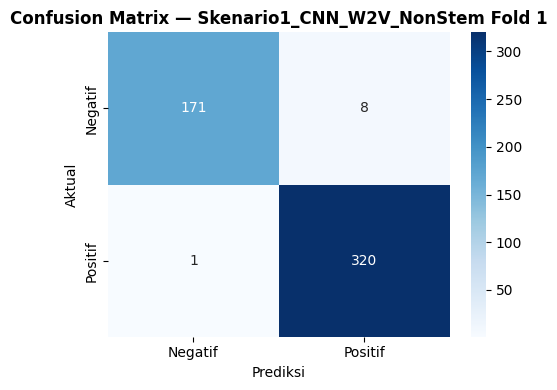

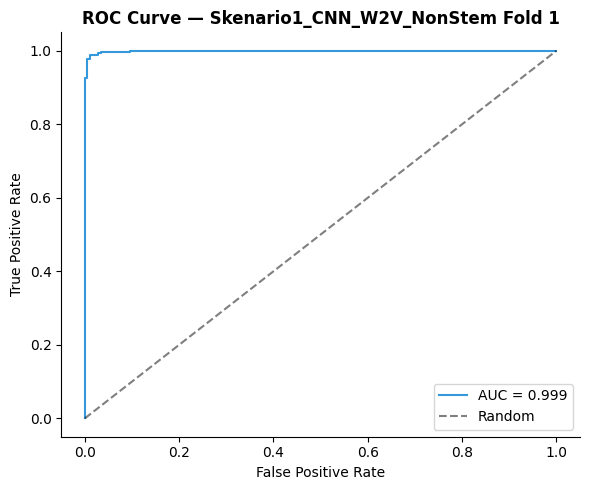


  ── Fold 2/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8040 - auc: 0.8821 - loss: 0.8024 - val_accuracy: 0.9420 - val_auc: 0.9864 - val_loss: 0.5303
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.9405 - auc: 0.9849 - loss: 0.5132 - val_accuracy: 0.9560 - val_auc: 0.9950 - val_loss: 0.4328
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9630 - auc: 0.9929 - loss: 0.4222 - val_accuracy: 0.9640 - val_auc: 0.9962 - val_loss: 0.3807
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9735 - auc: 0.9949 - loss: 0.3622 - val_accuracy: 0.9620 - val_auc: 0.9960 - val_loss: 0.3561
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.9810 - auc: 0.9970 - loss: 0.3113 - val_accuracy: 0.9640 - val_auc: 0.9965 - val_loss: 0.3130
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.9860 - auc: 0.9976 - loss: 0.2758 - val_accuracy: 0.9720 - val_auc: 0.9968 - val_los

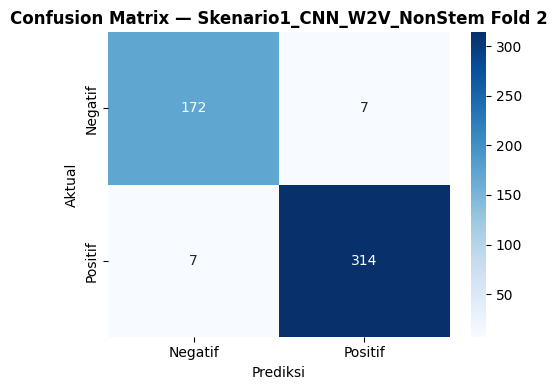

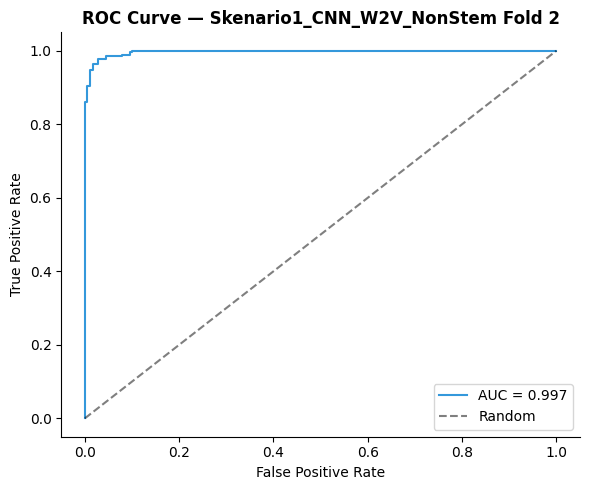


  ── Fold 3/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8080 - auc: 0.8679 - loss: 0.8265 - val_accuracy: 0.9080 - val_auc: 0.9778 - val_loss: 0.5895
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9380 - auc: 0.9809 - loss: 0.5254 - val_accuracy: 0.9600 - val_auc: 0.9905 - val_loss: 0.4384
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9640 - auc: 0.9926 - loss: 0.4143 - val_accuracy: 0.9620 - val_auc: 0.9919 - val_loss: 0.3891
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9760 - auc: 0.9963 - loss: 0.3454 - val_accuracy: 0.9680 - val_auc: 0.9930 - val_loss: 0.3456
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9780 - auc: 0.9958 - loss: 0.3109 - val_accuracy: 0.9760 - val_auc: 0.9920 - val_loss: 0.3137
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9820 - auc: 0.9980 - loss: 0.2587 - val_accuracy: 0.9740 - val_auc: 0.9923 - val_los

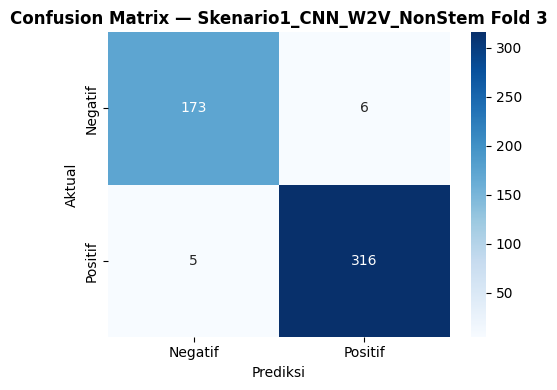

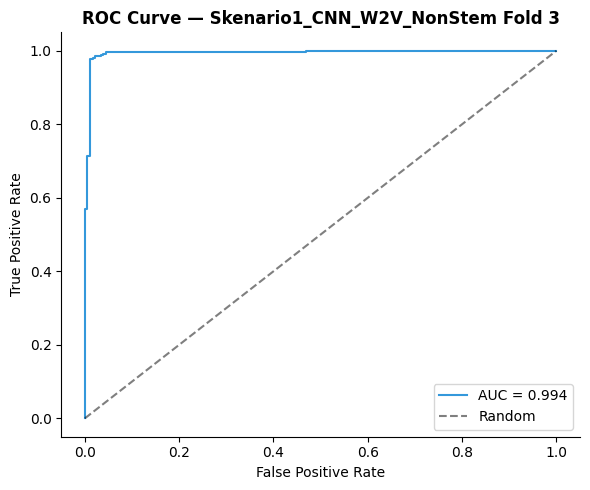


  ── Fold 4/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.8110 - auc: 0.8947 - loss: 0.7837 - val_accuracy: 0.9300 - val_auc: 0.9836 - val_loss: 0.5429
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9395 - auc: 0.9836 - loss: 0.5092 - val_accuracy: 0.9620 - val_auc: 0.9934 - val_loss: 0.4355
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9690 - auc: 0.9922 - loss: 0.4136 - val_accuracy: 0.9680 - val_auc: 0.9951 - val_loss: 0.3766
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9755 - auc: 0.9957 - loss: 0.3559 - val_accuracy: 0.9760 - val_auc: 0.9955 - val_loss: 0.3302
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9805 - auc: 0.9962 - loss: 0.3106 - val_accuracy: 0.9800 - val_auc: 0.9942 - val_loss: 0.3032
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9855 - auc: 0.9974 - loss: 0.2744 - val_accuracy: 0.9800 - val_auc: 0.9938 - val_los

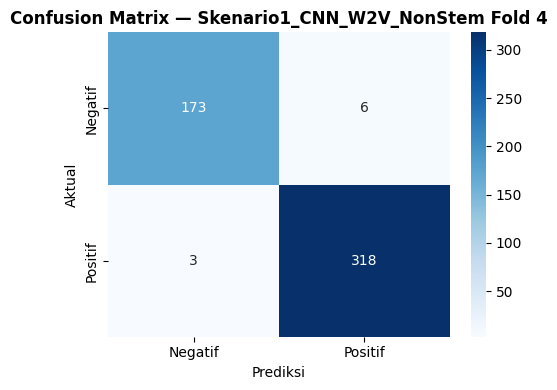

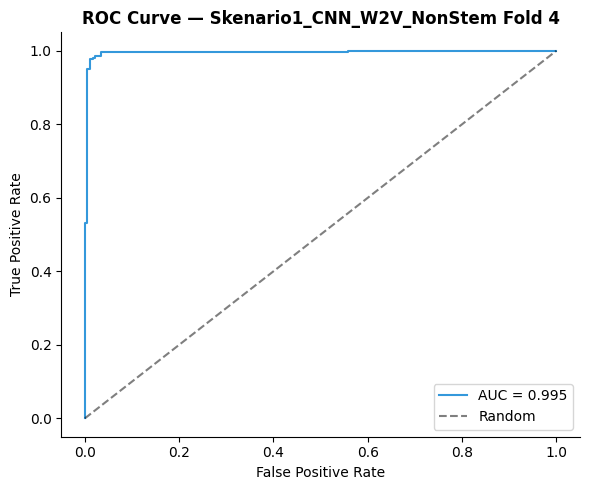


  ── Fold 5/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8395 - auc: 0.9037 - loss: 0.7654 - val_accuracy: 0.9620 - val_auc: 0.9932 - val_loss: 0.4873
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9405 - auc: 0.9834 - loss: 0.5029 - val_accuracy: 0.9760 - val_auc: 0.9973 - val_loss: 0.3950
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9615 - auc: 0.9921 - loss: 0.4119 - val_accuracy: 0.9780 - val_auc: 0.9980 - val_loss: 0.3456
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9745 - auc: 0.9965 - loss: 0.3441 - val_accuracy: 0.9800 - val_auc: 0.9979 - val_loss: 0.3102
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9790 - auc: 0.9961 - loss: 0.3057 - val_accuracy: 0.9780 - val_auc: 0.9981 - val_loss: 0.2790
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9845 - auc: 0.9969 - loss: 0.2647 - val_accuracy: 0.9800 - val_auc: 0.9982 - val_los

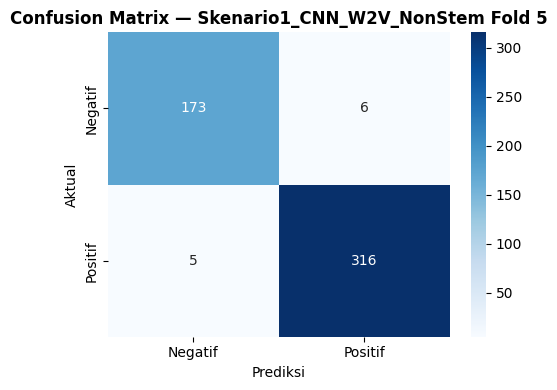

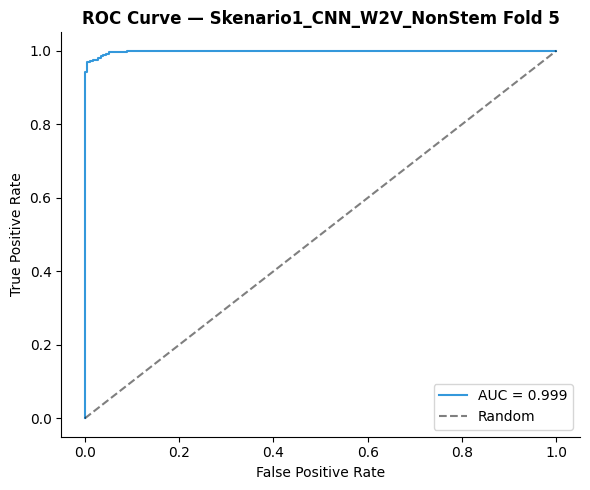


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task5_Service/Skenario1_CNN_W2V_NonStem/model.h5


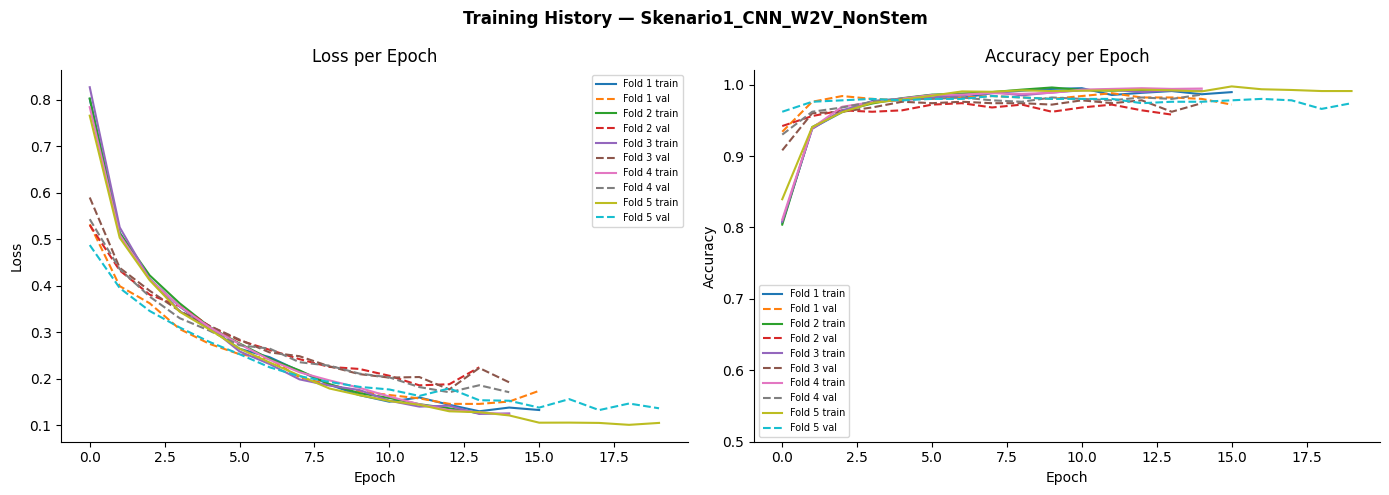


  ╔═ SELESAI: Skenario1_CNN_W2V_NonStem
  ║  avg Precision  : 0.9780 ± 0.0059
  ║  avg Recall     : 0.9750 ± 0.0033
  ║  avg F1 Macro   : 0.9764 ± 0.0044
  ║  avg Accuracy   : 0.9784 ± 0.0041
  ║  avg AUC        : 0.9967 ± 0.0021
  ║  avg RAM        : 2599.3 MB (20.0%)
  ║  avg CPU        : 13.1 %
  ║  avg Waktu      : 48.40 detik/fold
  ║  avg T/Epoch    : 3.04 detik/epoch
  ║  avg T/Step     : 0.0490 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 1 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[0])


  Training: Skenario2_CNN_W2V_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 1,351 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.7970 - auc: 0.8699 - loss: 0.8206 - val_accuracy: 0.9380 - val_auc: 0.9891 - val_loss: 0.5344
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9385 - auc: 0.9814 - loss: 0.5221 - val_accuracy: 0.9660 - val_auc: 0.9963 - val_loss: 0.4234
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9635 - auc: 0.9907 - loss: 0.4254 - val_accuracy: 0.9820 - val_auc: 0.9978 - val_loss: 0.3554
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9795 - auc: 0.9957 - loss: 0.3518 - val_accuracy: 0.9800 - val_auc: 0.9984 - val_loss: 0.3146
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9805 - auc: 0.9981 - loss: 0.3035 - val_accuracy: 0.98

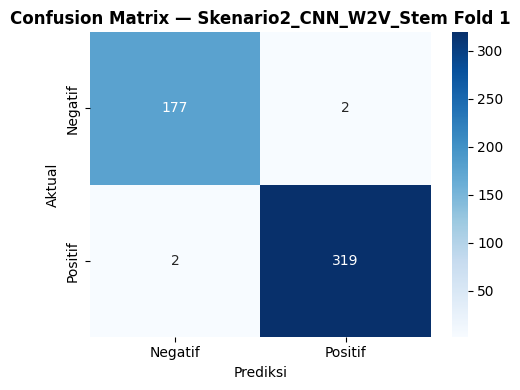

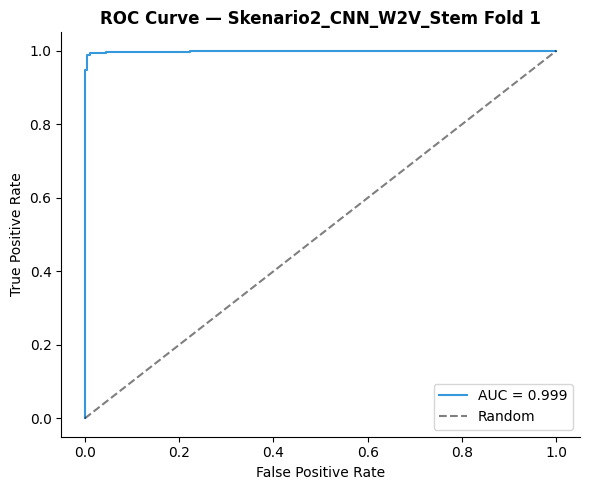


  ── Fold 2/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.7955 - auc: 0.8805 - loss: 0.7991 - val_accuracy: 0.9360 - val_auc: 0.9871 - val_loss: 0.5244
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9375 - auc: 0.9841 - loss: 0.5093 - val_accuracy: 0.9660 - val_auc: 0.9953 - val_loss: 0.4231
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9660 - auc: 0.9925 - loss: 0.4132 - val_accuracy: 0.9680 - val_auc: 0.9957 - val_loss: 0.3846
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9810 - auc: 0.9964 - loss: 0.3476 - val_accuracy: 0.9700 - val_auc: 0.9960 - val_loss: 0.3463
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9850 - auc: 0.9986 - loss: 0.2969 - val_accuracy: 0.9620 - val_auc: 0.9935 - val_loss: 0.3221
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9860 - auc: 0.9986 - loss: 0.2658 - val_accuracy: 0.9680 - val_auc: 0.9962 - val_los

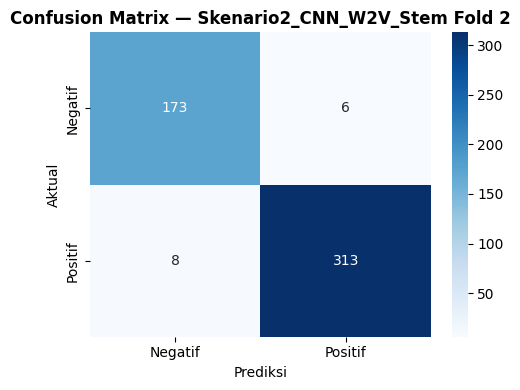

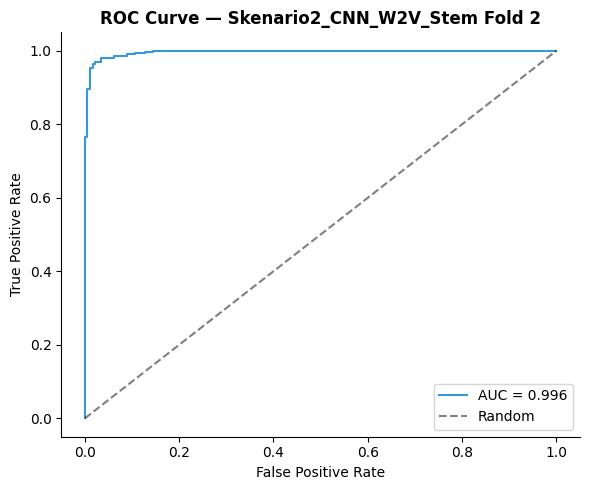


  ── Fold 3/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8180 - auc: 0.8832 - loss: 0.7920 - val_accuracy: 0.9340 - val_auc: 0.9816 - val_loss: 0.5440
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9300 - auc: 0.9809 - loss: 0.5259 - val_accuracy: 0.9620 - val_auc: 0.9925 - val_loss: 0.4362
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9555 - auc: 0.9899 - loss: 0.4335 - val_accuracy: 0.9740 - val_auc: 0.9929 - val_loss: 0.3860
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9755 - auc: 0.9962 - loss: 0.3607 - val_accuracy: 0.9700 - val_auc: 0.9934 - val_loss: 0.3499
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9775 - auc: 0.9974 - loss: 0.3193 - val_accuracy: 0.9680 - val_auc: 0.9927 - val_loss: 0.3241
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9810 - auc: 0.9972 - loss: 0.2859 - val_accuracy: 0.9720 - val_auc: 0.9929 - val_los

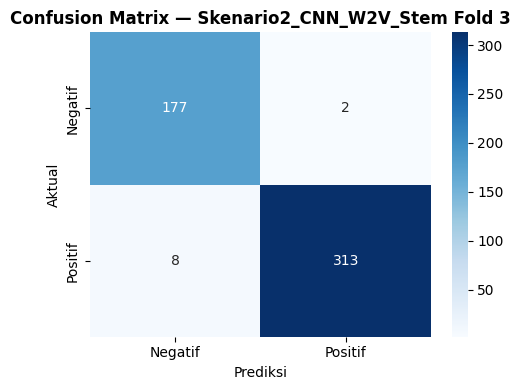

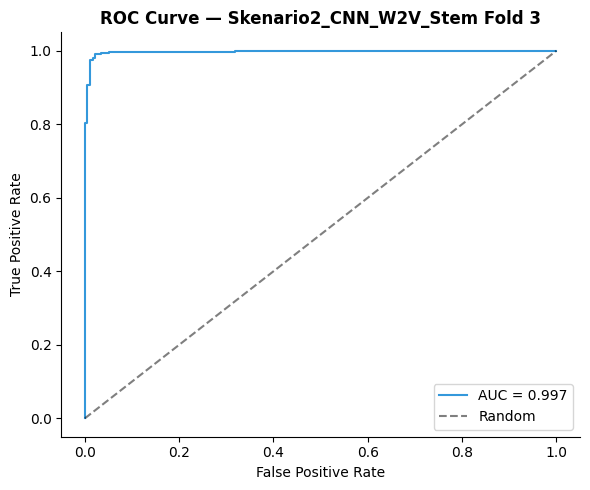


  ── Fold 4/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.7855 - auc: 0.8569 - loss: 0.8378 - val_accuracy: 0.9100 - val_auc: 0.9735 - val_loss: 0.5805
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9270 - auc: 0.9790 - loss: 0.5344 - val_accuracy: 0.9560 - val_auc: 0.9933 - val_loss: 0.4433
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9615 - auc: 0.9925 - loss: 0.4204 - val_accuracy: 0.9720 - val_auc: 0.9952 - val_loss: 0.3773
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9715 - auc: 0.9953 - loss: 0.3627 - val_accuracy: 0.9720 - val_auc: 0.9957 - val_loss: 0.3339
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9845 - auc: 0.9983 - loss: 0.2988 - val_accuracy: 0.9760 - val_auc: 0.9953 - val_loss: 0.3051
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9800 - auc: 0.9975 - loss: 0.2772 - val_accuracy: 0.9780 - val_auc: 0.9935 - val_los

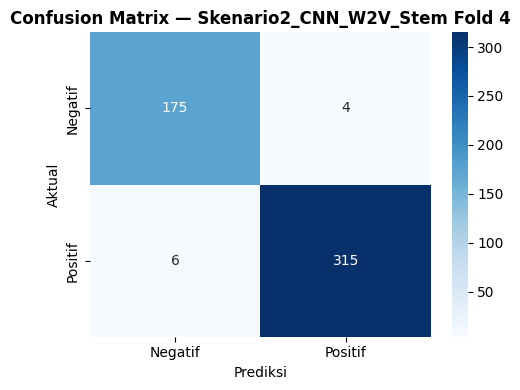

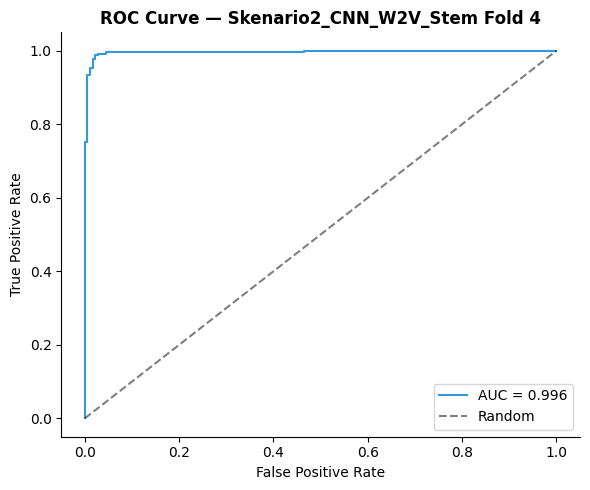


  ── Fold 5/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7965 - auc: 0.8541 - loss: 0.8397 - val_accuracy: 0.9500 - val_auc: 0.9887 - val_loss: 0.5227
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9310 - auc: 0.9789 - loss: 0.5428 - val_accuracy: 0.9740 - val_auc: 0.9968 - val_loss: 0.4155
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9650 - auc: 0.9914 - loss: 0.4321 - val_accuracy: 0.9800 - val_auc: 0.9981 - val_loss: 0.3639
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9760 - auc: 0.9957 - loss: 0.3693 - val_accuracy: 0.9820 - val_auc: 0.9982 - val_loss: 0.3358
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9800 - auc: 0.9970 - loss: 0.3224 - val_accuracy: 0.9840 - val_auc: 0.9986 - val_loss: 0.2902
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9850 - auc: 0.9976 - loss: 0.2865 - val_accuracy: 0.9800 - val_auc: 0.9985 - val_los

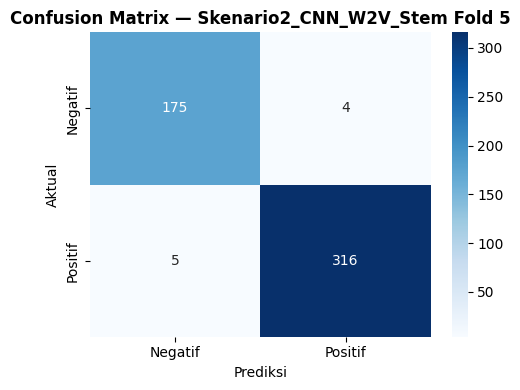

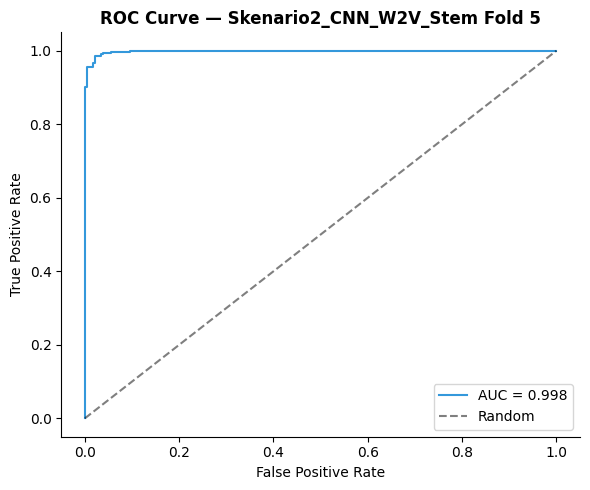


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task5_Service/Skenario2_CNN_W2V_Stem/model.h5


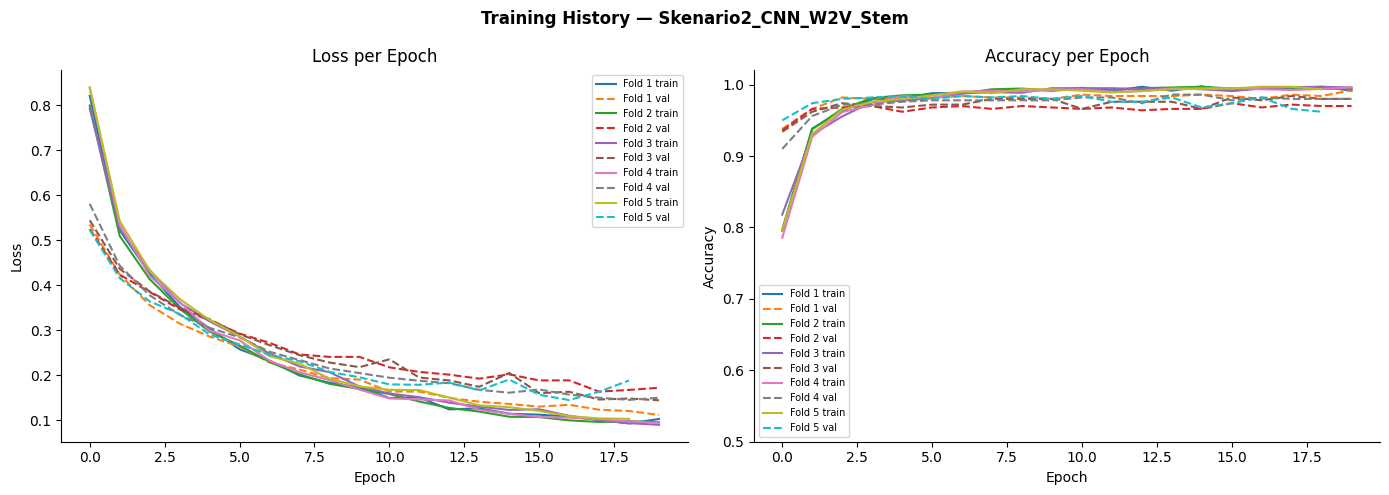


  ╔═ SELESAI: Skenario2_CNN_W2V_Stem
  ║  avg Precision  : 0.9784 ± 0.0083
  ║  avg Recall     : 0.9809 ± 0.0073
  ║  avg F1 Macro   : 0.9796 ± 0.0078
  ║  avg Accuracy   : 0.9812 ± 0.0072
  ║  avg AUC        : 0.9973 ± 0.0012
  ║  avg RAM        : 2691.6 MB (20.7%)
  ║  avg CPU        : 3.2 %
  ║  avg Waktu      : 53.66 detik/fold
  ║  avg T/Epoch    : 2.70 detik/epoch
  ║  avg T/Step     : 0.0436 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 2 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[1])


  Training: Skenario3_CNN_FT_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.7740 - auc: 0.8386 - loss: 0.8583 - val_accuracy: 0.9020 - val_auc: 0.9822 - val_loss: 0.5987
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9165 - auc: 0.9760 - loss: 0.5472 - val_accuracy: 0.9600 - val_auc: 0.9962 - val_loss: 0.4457
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9450 - auc: 0.9855 - loss: 0.4613 - val_accuracy: 0.9760 - val_auc: 0.9973 - val_loss: 0.3848
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9635 - auc: 0.9922 - loss: 0.3892 - val_accuracy: 0.9780 - val_auc: 0.9980 - val_loss: 0.3280
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9730 - auc: 0.9956 - loss: 0.3288 - val_accuracy: 0.9780

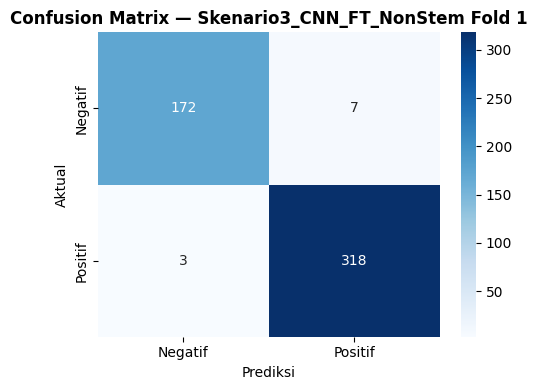

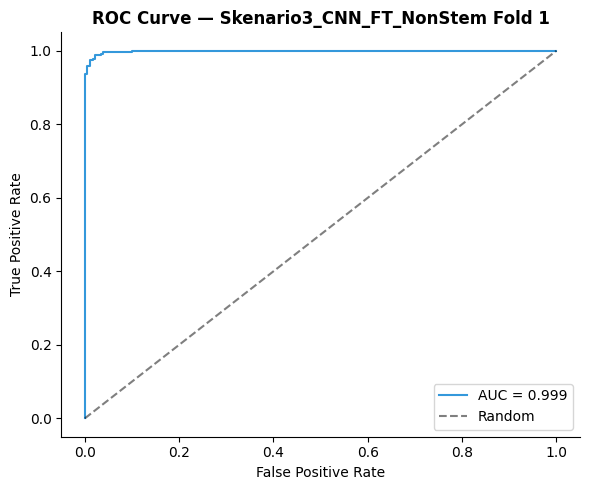


  ── Fold 2/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.8015 - auc: 0.8783 - loss: 0.7992 - val_accuracy: 0.9340 - val_auc: 0.9830 - val_loss: 0.5433
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9230 - auc: 0.9797 - loss: 0.5230 - val_accuracy: 0.9660 - val_auc: 0.9933 - val_loss: 0.4329
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9600 - auc: 0.9914 - loss: 0.4188 - val_accuracy: 0.9620 - val_auc: 0.9945 - val_loss: 0.3852
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9720 - auc: 0.9948 - loss: 0.3561 - val_accuracy: 0.9620 - val_auc: 0.9928 - val_loss: 0.3507
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9815 - auc: 0.9963 - loss: 0.3123 - val_accuracy: 0.9640 - val_auc: 0.9933 - val_loss: 0.3211
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9815 - auc: 0.9982 - loss: 0.2732 - val_accuracy: 0.9660 - val_auc: 0.9961 - val_los

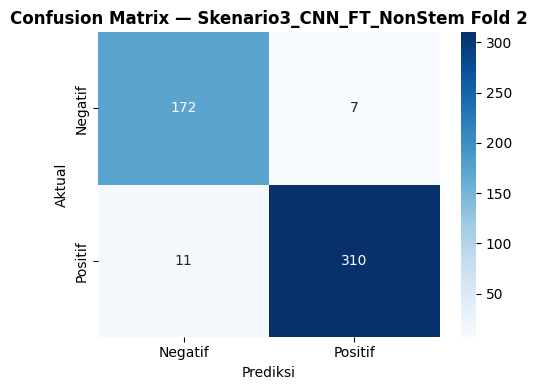

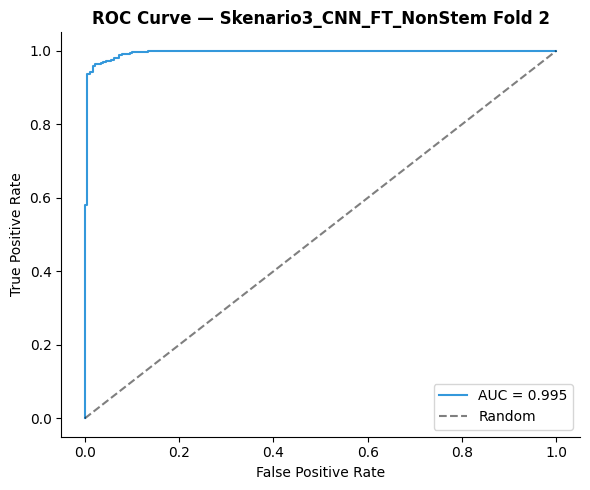


  ── Fold 3/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8050 - auc: 0.8767 - loss: 0.8107 - val_accuracy: 0.9240 - val_auc: 0.9771 - val_loss: 0.5664
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9310 - auc: 0.9790 - loss: 0.5362 - val_accuracy: 0.9560 - val_auc: 0.9893 - val_loss: 0.4573
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9590 - auc: 0.9922 - loss: 0.4278 - val_accuracy: 0.9640 - val_auc: 0.9919 - val_loss: 0.4036
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9680 - auc: 0.9924 - loss: 0.3834 - val_accuracy: 0.9660 - val_auc: 0.9928 - val_loss: 0.3641
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9735 - auc: 0.9969 - loss: 0.3237 - val_accuracy: 0.9720 - val_auc: 0.9900 - val_loss: 0.3303
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9785 - auc: 0.9963 - loss: 0.2934 - val_accuracy: 0.9700 - val_auc: 0.9929 - val_los

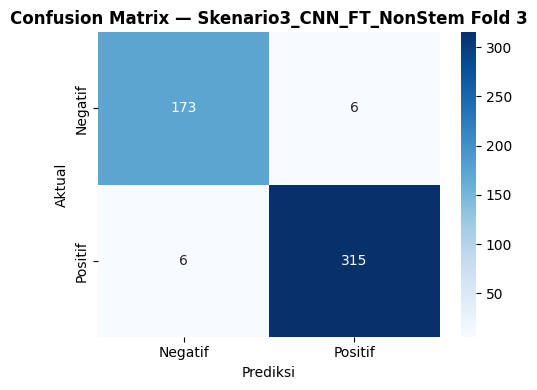

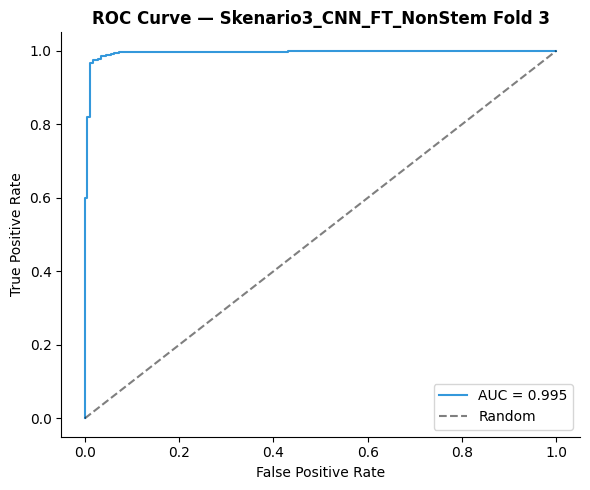


  ── Fold 4/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8015 - auc: 0.8862 - loss: 0.7916 - val_accuracy: 0.9180 - val_auc: 0.9773 - val_loss: 0.5624
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9390 - auc: 0.9798 - loss: 0.5216 - val_accuracy: 0.9480 - val_auc: 0.9933 - val_loss: 0.4551
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9570 - auc: 0.9897 - loss: 0.4267 - val_accuracy: 0.9600 - val_auc: 0.9950 - val_loss: 0.3739
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9725 - auc: 0.9947 - loss: 0.3560 - val_accuracy: 0.9480 - val_auc: 0.9951 - val_loss: 0.3858
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9710 - auc: 0.9952 - loss: 0.3202 - val_accuracy: 0.9620 - val_auc: 0.9949 - val_loss: 0.3135
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9825 - auc: 0.9978 - loss: 0.2722 - val_accuracy: 0.9800 - val_auc: 0.9931 - val_los

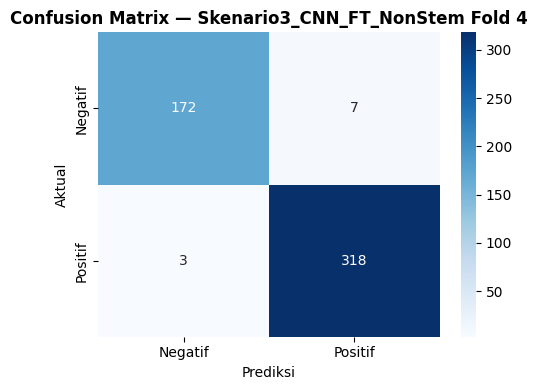

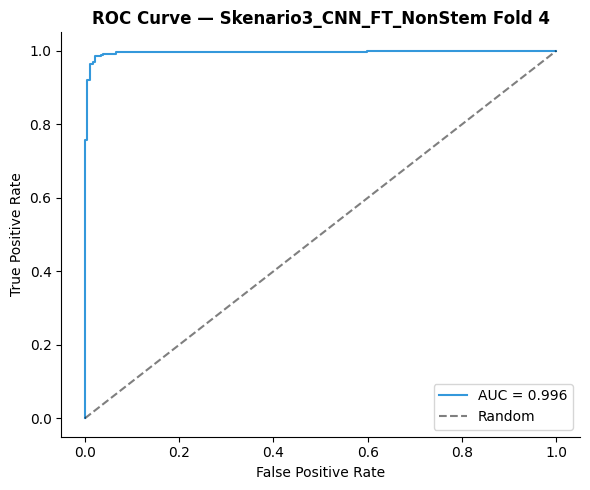


  ── Fold 5/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.7785 - auc: 0.8401 - loss: 0.8544 - val_accuracy: 0.9480 - val_auc: 0.9889 - val_loss: 0.5256
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9195 - auc: 0.9736 - loss: 0.5508 - val_accuracy: 0.9620 - val_auc: 0.9966 - val_loss: 0.4137
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9560 - auc: 0.9901 - loss: 0.4319 - val_accuracy: 0.9740 - val_auc: 0.9980 - val_loss: 0.3581
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9685 - auc: 0.9936 - loss: 0.3731 - val_accuracy: 0.9740 - val_auc: 0.9985 - val_loss: 0.3173
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9775 - auc: 0.9956 - loss: 0.3225 - val_accuracy: 0.9800 - val_auc: 0.9987 - val_loss: 0.2835
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9775 - auc: 0.9968 - loss: 0.2860 - val_accuracy: 0.9780 - val_auc: 0.9987 - val_los

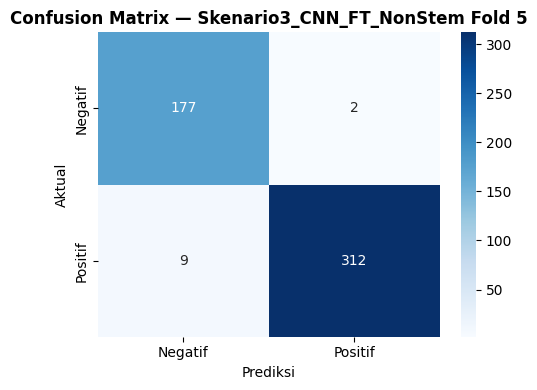

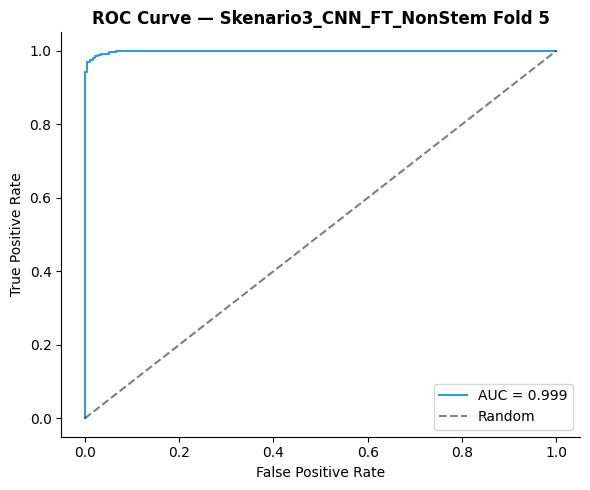


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task5_Service/Skenario3_CNN_FT_NonStem/model.h5


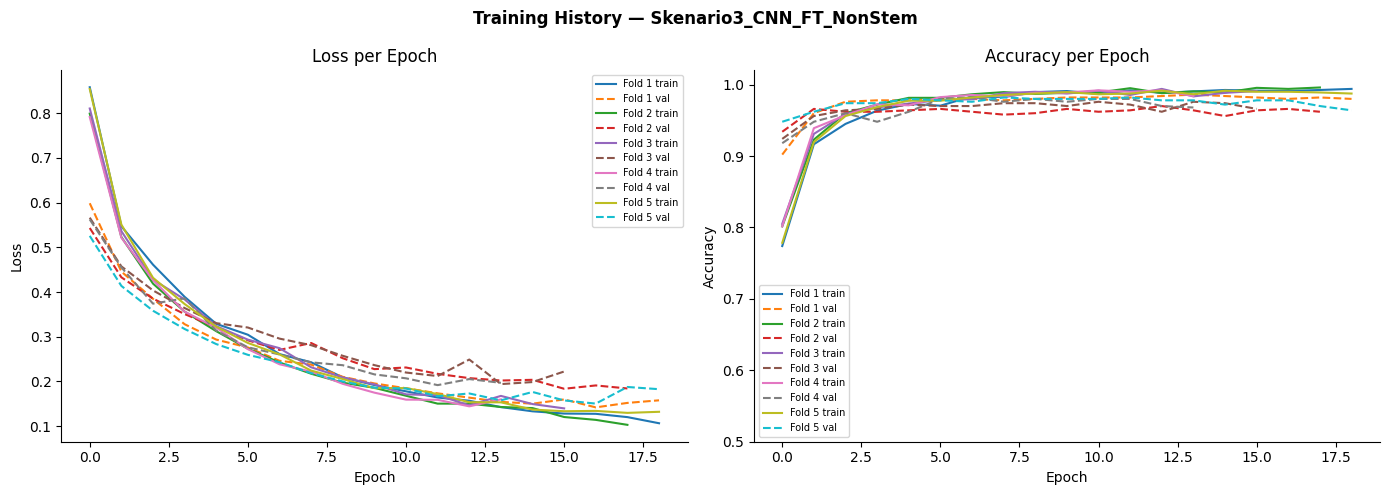


  ╔═ SELESAI: Skenario3_CNN_FT_NonStem
  ║  avg Precision  : 0.9733 ± 0.0089
  ║  avg Recall     : 0.9738 ± 0.0063
  ║  avg F1 Macro   : 0.9735 ± 0.0072
  ║  avg Accuracy   : 0.9756 ± 0.0067
  ║  avg AUC        : 0.9966 ± 0.0021
  ║  avg RAM        : 2832.4 MB (21.8%)
  ║  avg CPU        : 2.9 %
  ║  avg Waktu      : 48.72 detik/fold
  ║  avg T/Epoch    : 2.82 detik/epoch
  ║  avg T/Step     : 0.0454 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 3 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[2])


  Training: Skenario4_CNN_FT_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.7840 - auc: 0.8509 - loss: 0.8397 - val_accuracy: 0.9240 - val_auc: 0.9885 - val_loss: 0.5650
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9305 - auc: 0.9781 - loss: 0.5292 - val_accuracy: 0.9680 - val_auc: 0.9960 - val_loss: 0.4159
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9555 - auc: 0.9891 - loss: 0.4330 - val_accuracy: 0.9820 - val_auc: 0.9970 - val_loss: 0.3595
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9700 - auc: 0.9942 - loss: 0.3558 - val_accuracy: 0.9800 - val_auc: 0.9973 - val_loss: 0.3185
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9820 - auc: 0.9963 - loss: 0.3051 - val_accuracy: 0.9800 - 

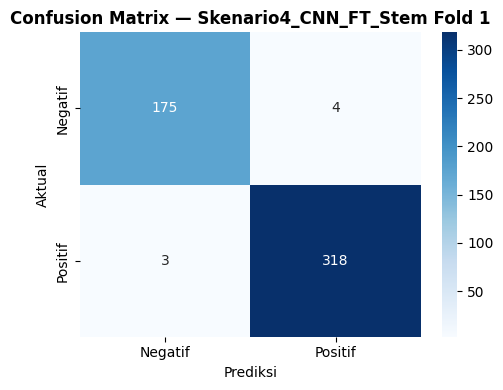

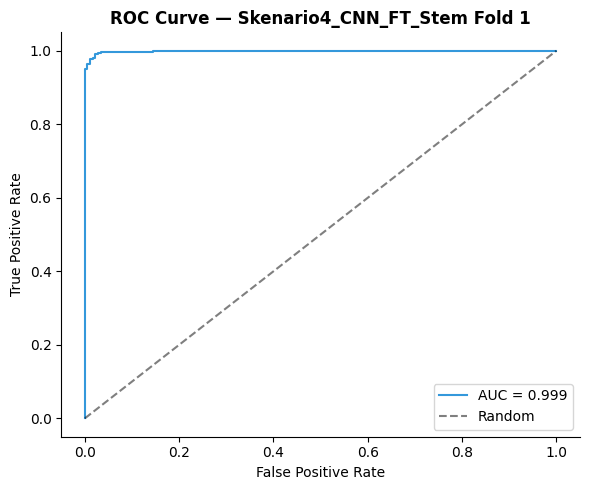


  ── Fold 2/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.7925 - auc: 0.8632 - loss: 0.8207 - val_accuracy: 0.9360 - val_auc: 0.9851 - val_loss: 0.5415
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9410 - auc: 0.9837 - loss: 0.5079 - val_accuracy: 0.9500 - val_auc: 0.9928 - val_loss: 0.4427
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9650 - auc: 0.9946 - loss: 0.3979 - val_accuracy: 0.9560 - val_auc: 0.9941 - val_loss: 0.3874
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9710 - auc: 0.9958 - loss: 0.3466 - val_accuracy: 0.9640 - val_auc: 0.9940 - val_loss: 0.3500
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9815 - auc: 0.9971 - loss: 0.2960 - val_accuracy: 0.9600 - val_auc: 0.9927 - val_loss: 0.3229
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9830 - auc: 0.9981 - loss: 0.2642 - val_accuracy: 0.9640 - val_auc: 0.9932 - val_los

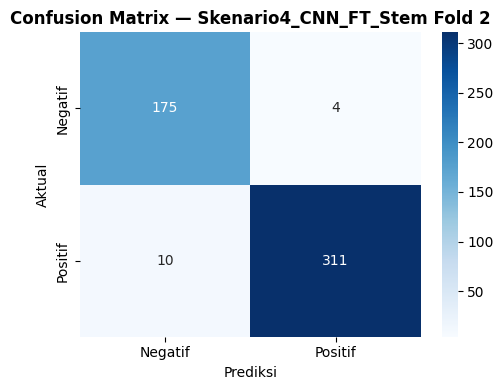

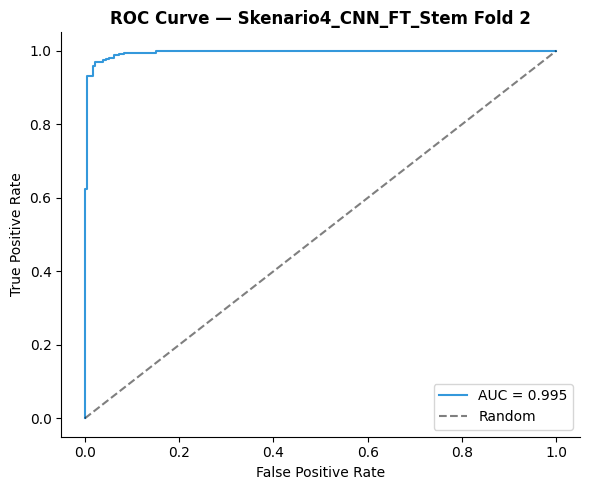


  ── Fold 3/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.7935 - auc: 0.8660 - loss: 0.8211 - val_accuracy: 0.9260 - val_auc: 0.9768 - val_loss: 0.5691
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9395 - auc: 0.9806 - loss: 0.5148 - val_accuracy: 0.9560 - val_auc: 0.9930 - val_loss: 0.4304
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9545 - auc: 0.9903 - loss: 0.4183 - val_accuracy: 0.9740 - val_auc: 0.9955 - val_loss: 0.3644
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9650 - auc: 0.9930 - loss: 0.3643 - val_accuracy: 0.9720 - val_auc: 0.9956 - val_loss: 0.3287
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9745 - auc: 0.9950 - loss: 0.3123 - val_accuracy: 0.9720 - val_auc: 0.9960 - val_loss: 0.3015
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9760 - auc: 0.9962 - loss: 0.2789 - val_accuracy: 0.9640 - val_auc: 0.9949 - val_los

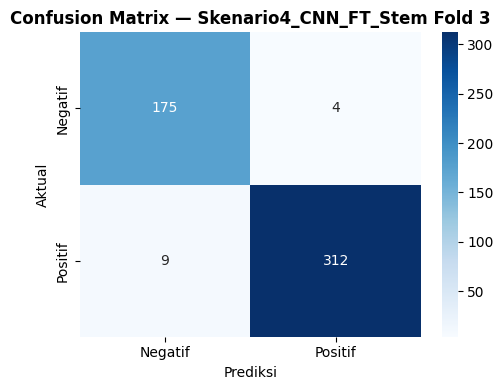

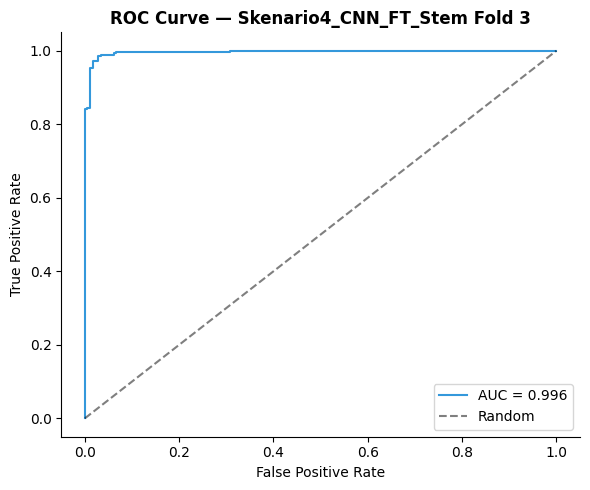


  ── Fold 4/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.7960 - auc: 0.8811 - loss: 0.7964 - val_accuracy: 0.9260 - val_auc: 0.9808 - val_loss: 0.5454
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9360 - auc: 0.9821 - loss: 0.5094 - val_accuracy: 0.9460 - val_auc: 0.9941 - val_loss: 0.4426
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9570 - auc: 0.9925 - loss: 0.4112 - val_accuracy: 0.9780 - val_auc: 0.9957 - val_loss: 0.3580
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9705 - auc: 0.9955 - loss: 0.3453 - val_accuracy: 0.9860 - val_auc: 0.9954 - val_loss: 0.3160
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9800 - auc: 0.9972 - loss: 0.3013 - val_accuracy: 0.9840 - val_auc: 0.9958 - val_loss: 0.2858
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9870 - auc: 0.9989 - loss: 0.2549 - val_accuracy: 0.9860 - val_auc: 0.9935 - val_los

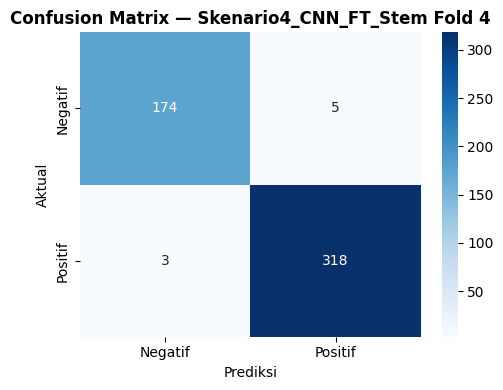

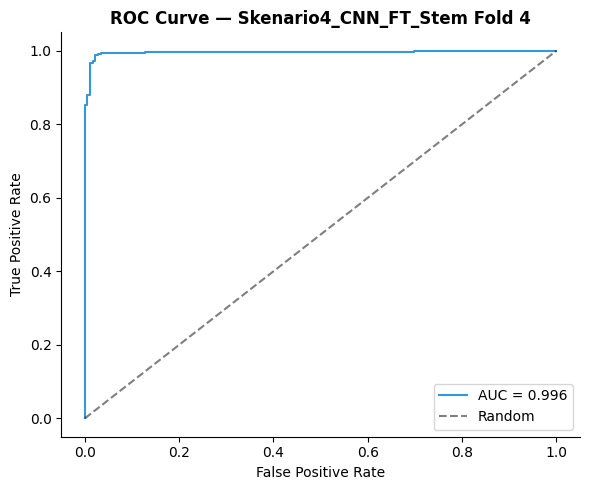


  ── Fold 5/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.7575 - auc: 0.8122 - loss: 0.8824 - val_accuracy: 0.9400 - val_auc: 0.9856 - val_loss: 0.5517
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9265 - auc: 0.9752 - loss: 0.5379 - val_accuracy: 0.9680 - val_auc: 0.9969 - val_loss: 0.3988
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9480 - auc: 0.9860 - loss: 0.4442 - val_accuracy: 0.9760 - val_auc: 0.9979 - val_loss: 0.3413
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9635 - auc: 0.9939 - loss: 0.3621 - val_accuracy: 0.9820 - val_auc: 0.9983 - val_loss: 0.3005
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9735 - auc: 0.9944 - loss: 0.3204 - val_accuracy: 0.9720 - val_auc: 0.9987 - val_loss: 0.2934
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9760 - auc: 0.9961 - loss: 0.2811 - val_accuracy: 0.9860 - val_auc: 0.9988 - val_los

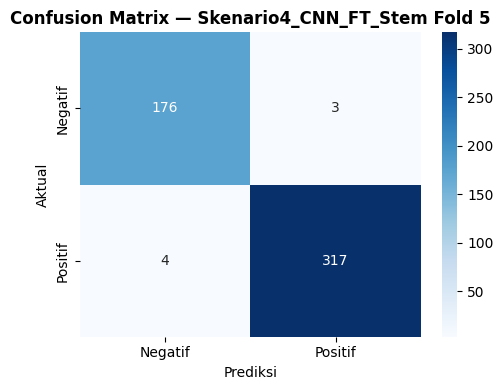

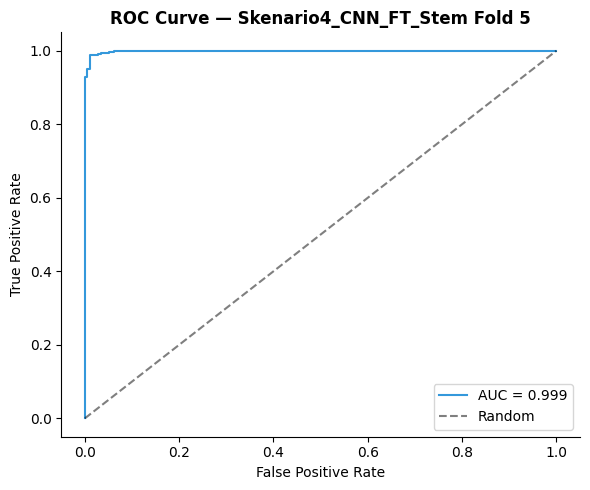


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task5_Service/Skenario4_CNN_FT_Stem/model.h5


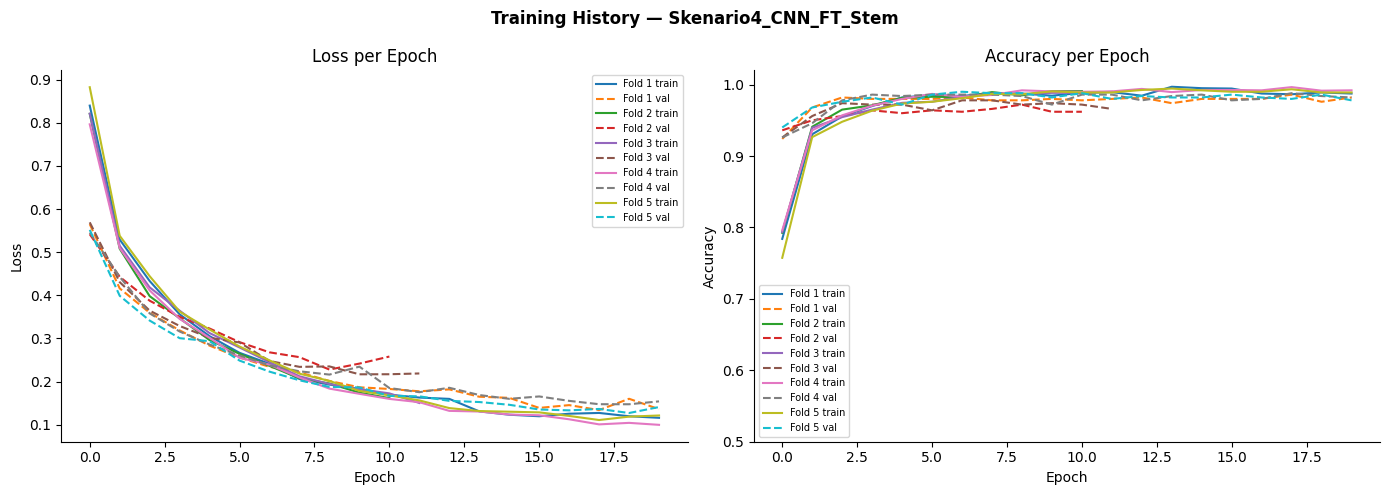


  ╔═ SELESAI: Skenario4_CNN_FT_Stem
  ║  avg Precision  : 0.9778 ± 0.0091
  ║  avg Recall     : 0.9798 ± 0.0055
  ║  avg F1 Macro   : 0.9787 ± 0.0073
  ║  avg Accuracy   : 0.9804 ± 0.0068
  ║  avg AUC        : 0.9970 ± 0.0018
  ║  avg RAM        : 2933.2 MB (22.6%)
  ║  avg CPU        : 11.6 %
  ║  avg Waktu      : 48.88 detik/fold
  ║  avg T/Epoch    : 2.90 detik/epoch
  ║  avg T/Step     : 0.0467 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 4 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[3])


  Training: Skenario5_BiLSTM_W2V_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 166ms/step - accuracy: 0.7520 - auc: 0.8279 - loss: 0.5616 - val_accuracy: 0.8980 - val_auc: 0.9669 - val_loss: 0.3351
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.8995 - auc: 0.9494 - loss: 0.3131 - val_accuracy: 0.9300 - val_auc: 0.9821 - val_loss: 0.2279
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.9170 - auc: 0.9637 - loss: 0.2655 - val_accuracy: 0.9440 - val_auc: 0.9894 - val_loss: 0.1816
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.9355 - auc: 0.9771 - loss: 0.2093 - val_accuracy: 0.9520 - val_auc: 0.9915 - val_loss: 0.1586
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.9385 - auc: 0.9818 - loss: 0.1895 - val_

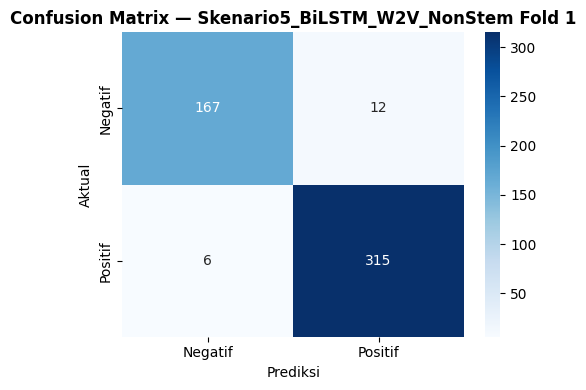

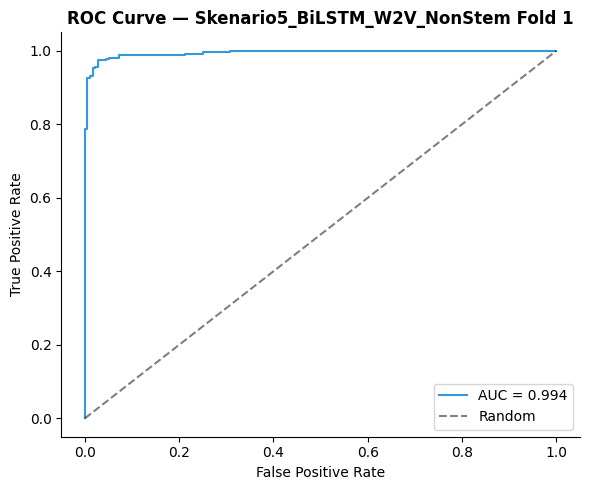


  ── Fold 2/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 168ms/step - accuracy: 0.7565 - auc: 0.8461 - loss: 0.5345 - val_accuracy: 0.8900 - val_auc: 0.9640 - val_loss: 0.3090
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.8955 - auc: 0.9539 - loss: 0.3097 - val_accuracy: 0.9200 - val_auc: 0.9791 - val_loss: 0.2326
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9250 - auc: 0.9714 - loss: 0.2460 - val_accuracy: 0.9360 - val_auc: 0.9865 - val_loss: 0.1927
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.9260 - auc: 0.9709 - loss: 0.2401 - val_accuracy: 0.9460 - val_auc: 0.9896 - val_loss: 0.1699
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step - accuracy: 0.9435 - auc: 0.9825 - loss: 0.1912 - val_accuracy: 0.9620 - val_auc: 0.9903 - val_loss: 0.1530
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.9515 - auc: 0.9859 - loss: 0.1701 - val_accuracy: 0.9600 - val_auc: 0.990

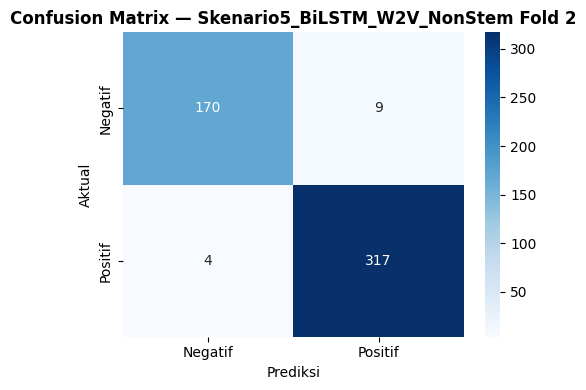

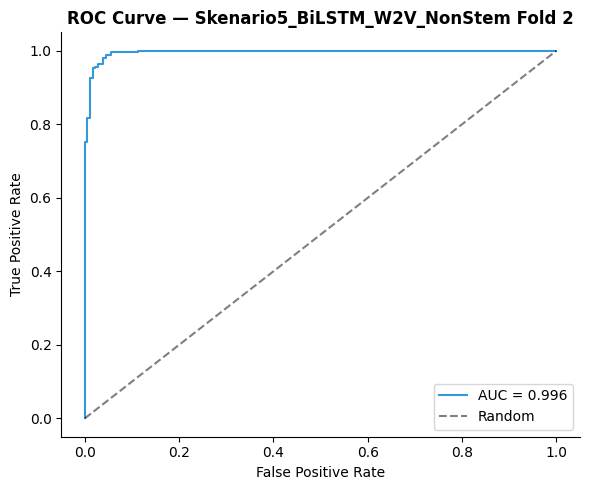


  ── Fold 3/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 154ms/step - accuracy: 0.7740 - auc: 0.8697 - loss: 0.5133 - val_accuracy: 0.8740 - val_auc: 0.9569 - val_loss: 0.3326
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 209ms/step - accuracy: 0.8985 - auc: 0.9467 - loss: 0.3203 - val_accuracy: 0.8820 - val_auc: 0.9704 - val_loss: 0.3001
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 163ms/step - accuracy: 0.9180 - auc: 0.9712 - loss: 0.2455 - val_accuracy: 0.9220 - val_auc: 0.9780 - val_loss: 0.2291
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.9305 - auc: 0.9740 - loss: 0.2270 - val_accuracy: 0.9340 - val_auc: 0.9793 - val_loss: 0.2026
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - accuracy: 0.9380 - auc: 0.9809 - loss: 0.1950 - val_accuracy: 0.9100 - val_auc: 0.9778 - val_loss: 0.2427
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.9425 - auc: 0.9840 - loss: 0.1791 - val_accuracy: 0.9440 - val_auc: 0.98

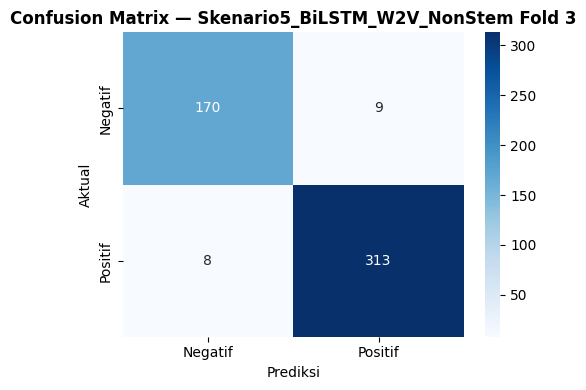

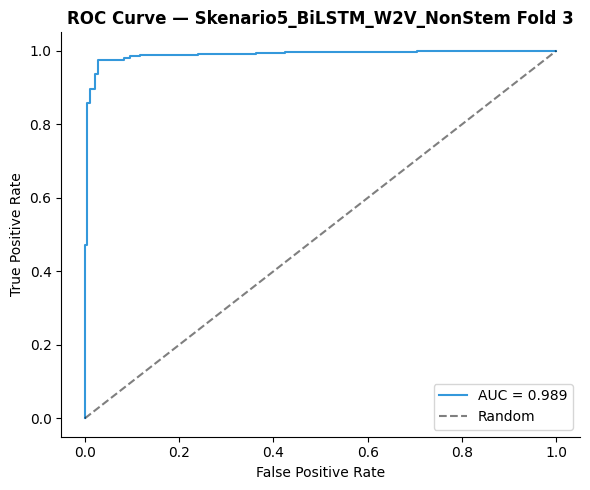


  ── Fold 4/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 167ms/step - accuracy: 0.8040 - auc: 0.8878 - loss: 0.4792 - val_accuracy: 0.8920 - val_auc: 0.9649 - val_loss: 0.3103
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 144ms/step - accuracy: 0.8990 - auc: 0.9566 - loss: 0.2959 - val_accuracy: 0.9200 - val_auc: 0.9781 - val_loss: 0.2389
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - accuracy: 0.9230 - auc: 0.9705 - loss: 0.2459 - val_accuracy: 0.9320 - val_auc: 0.9853 - val_loss: 0.2268
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.9340 - auc: 0.9801 - loss: 0.2042 - val_accuracy: 0.9480 - val_auc: 0.9886 - val_loss: 0.1635
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.9455 - auc: 0.9839 - loss: 0.1794 - val_accuracy: 0.9660 - val_auc: 0.9923 - val_loss: 0.1392
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.9490 - auc: 0.9857 - loss: 0.1718 - val_accuracy: 0.9680 - val_auc: 0.992

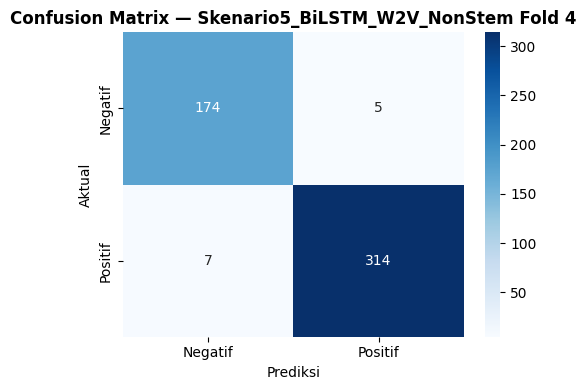

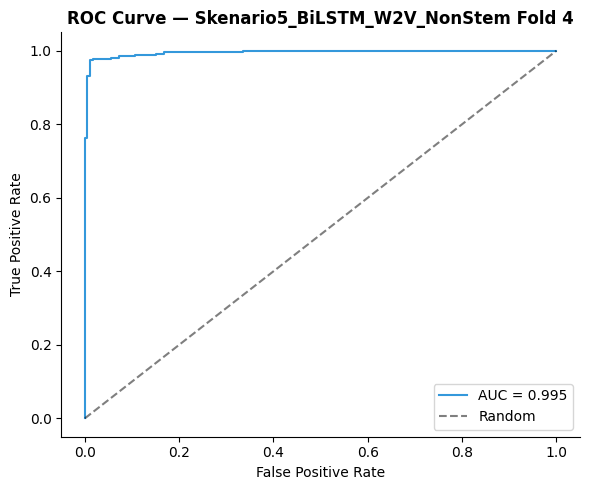


  ── Fold 5/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 164ms/step - accuracy: 0.7905 - auc: 0.8739 - loss: 0.5118 - val_accuracy: 0.9240 - val_auc: 0.9784 - val_loss: 0.2442
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.8945 - auc: 0.9477 - loss: 0.3243 - val_accuracy: 0.9360 - val_auc: 0.9870 - val_loss: 0.2017
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.9200 - auc: 0.9696 - loss: 0.2551 - val_accuracy: 0.9600 - val_auc: 0.9936 - val_loss: 0.1457
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 154ms/step - accuracy: 0.9335 - auc: 0.9808 - loss: 0.2097 - val_accuracy: 0.9600 - val_auc: 0.9940 - val_loss: 0.1394
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.9465 - auc: 0.9845 - loss: 0.1846 - val_accuracy: 0.9580 - val_auc: 0.9945 - val_loss: 0.1405
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9505 - auc: 0.9836 - loss: 0.1819 - val_accuracy: 0.9720 - val_auc: 0.994

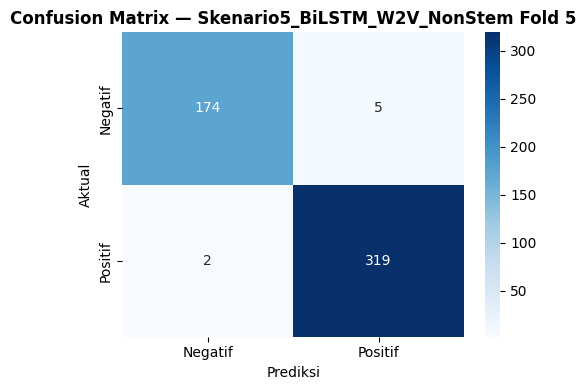

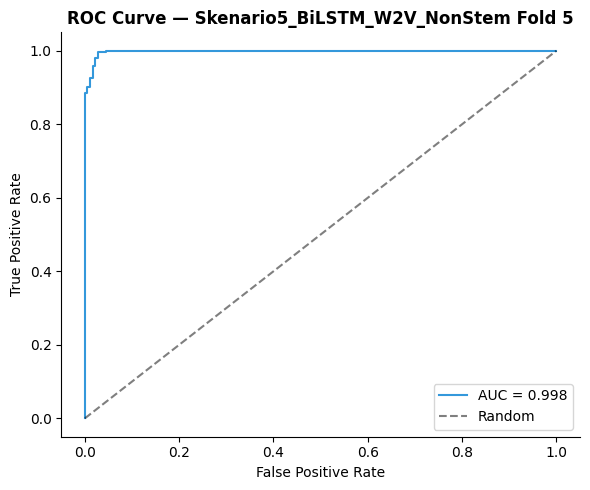


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task5_Service/Skenario5_BiLSTM_W2V_NonStem/model.h5


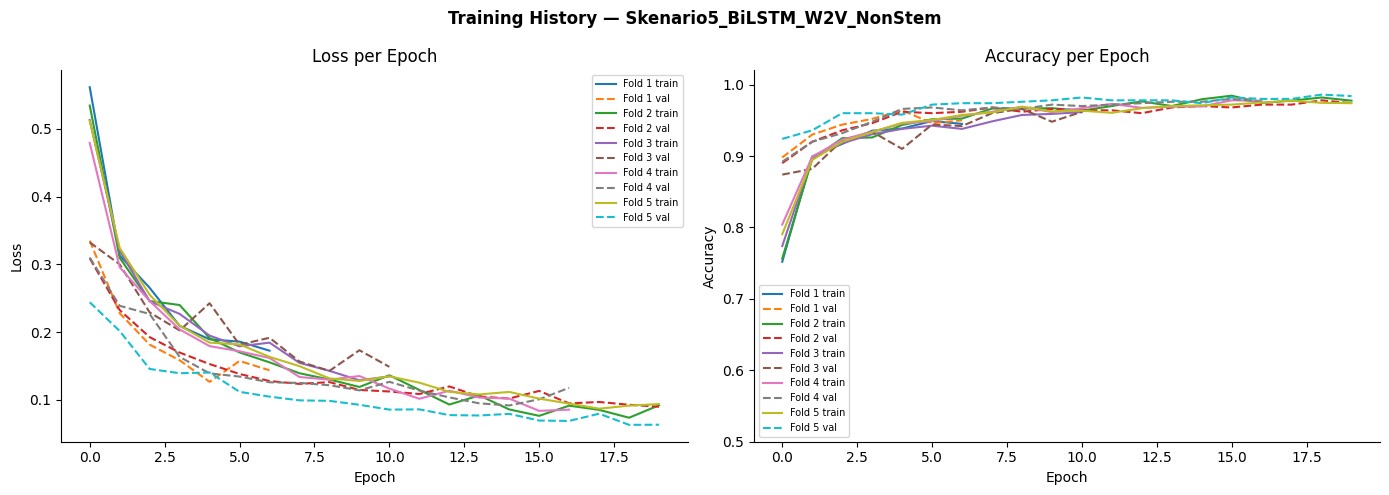


  ╔═ SELESAI: Skenario5_BiLSTM_W2V_NonStem
  ║  avg Precision  : 0.9724 ± 0.0094
  ║  avg Recall     : 0.9692 ± 0.0102
  ║  avg F1 Macro   : 0.9707 ± 0.0096
  ║  avg Accuracy   : 0.9732 ± 0.0088
  ║  avg AUC        : 0.9944 ± 0.0034
  ║  avg RAM        : 3223.9 MB (24.8%)
  ║  avg CPU        : 1.8 %
  ║  avg Waktu      : 164.05 detik/fold
  ║  avg T/Epoch    : 10.97 detik/epoch
  ║  avg T/Step     : 0.1770 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 5 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[4])


  Training: Skenario6_BiLSTM_W2V_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 1,351 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 157ms/step - accuracy: 0.7710 - auc: 0.8492 - loss: 0.5343 - val_accuracy: 0.9120 - val_auc: 0.9713 - val_loss: 0.3168
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.9005 - auc: 0.9520 - loss: 0.3121 - val_accuracy: 0.9340 - val_auc: 0.9836 - val_loss: 0.2118
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9195 - auc: 0.9670 - loss: 0.2555 - val_accuracy: 0.9420 - val_auc: 0.9881 - val_loss: 0.1875
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - accuracy: 0.9325 - auc: 0.9801 - loss: 0.2055 - val_accuracy: 0.9500 - val_auc: 0.9911 - val_loss: 0.1567
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.9420 - auc: 0.9813 - loss: 0.1916 - val_ac

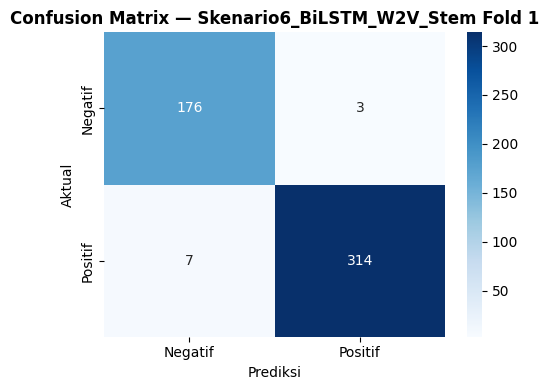

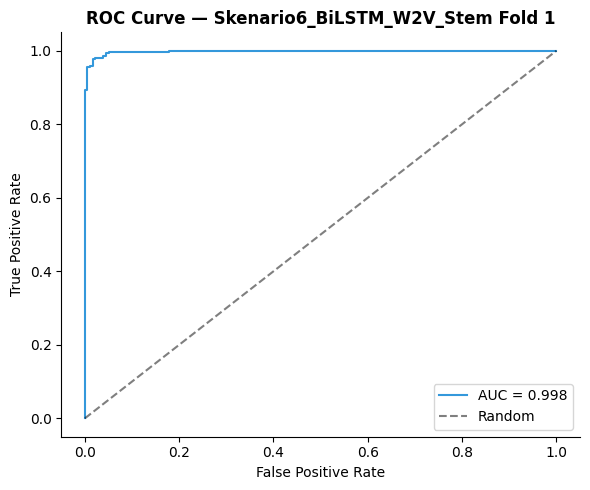


  ── Fold 2/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 173ms/step - accuracy: 0.7970 - auc: 0.8801 - loss: 0.4995 - val_accuracy: 0.9200 - val_auc: 0.9721 - val_loss: 0.2760
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.9110 - auc: 0.9593 - loss: 0.2947 - val_accuracy: 0.9360 - val_auc: 0.9816 - val_loss: 0.2181
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 166ms/step - accuracy: 0.9295 - auc: 0.9725 - loss: 0.2400 - val_accuracy: 0.9440 - val_auc: 0.9856 - val_loss: 0.1921
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 164ms/step - accuracy: 0.9370 - auc: 0.9807 - loss: 0.2037 - val_accuracy: 0.9520 - val_auc: 0.9860 - val_loss: 0.1796
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.9430 - auc: 0.9840 - loss: 0.1860 - val_accuracy: 0.9420 - val_auc: 0.9845 - val_loss: 0.1925
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9480 - auc: 0.9819 - loss: 0.1848 - val_accuracy: 0.9420 - val_auc: 0.99

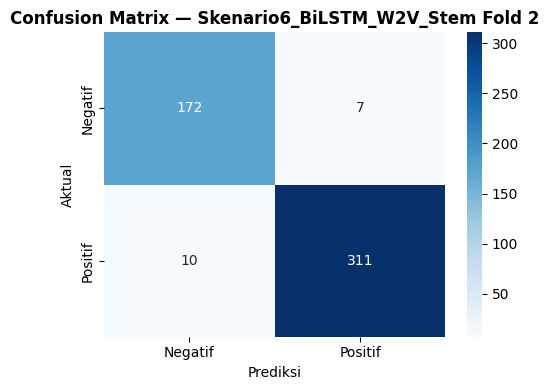

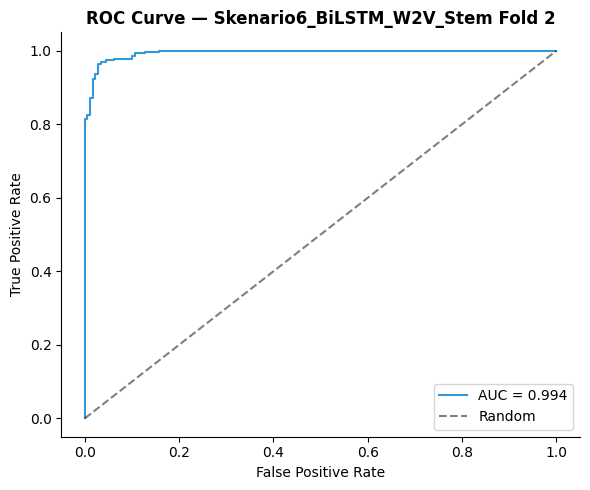


  ── Fold 3/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - accuracy: 0.7850 - auc: 0.8748 - loss: 0.5005 - val_accuracy: 0.8780 - val_auc: 0.9588 - val_loss: 0.3241
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.9075 - auc: 0.9562 - loss: 0.2963 - val_accuracy: 0.8840 - val_auc: 0.9732 - val_loss: 0.2758
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 152ms/step - accuracy: 0.9190 - auc: 0.9720 - loss: 0.2448 - val_accuracy: 0.8940 - val_auc: 0.9779 - val_loss: 0.2525
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.9245 - auc: 0.9752 - loss: 0.2232 - val_accuracy: 0.9180 - val_auc: 0.9810 - val_loss: 0.2110
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.9375 - auc: 0.9818 - loss: 0.1917 - val_accuracy: 0.9260 - val_auc: 0.9823 - val_loss: 0.2045
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.9475 - auc: 0.9863 - loss: 0.1663 - val_accuracy: 0.9440 - val_auc: 0.984

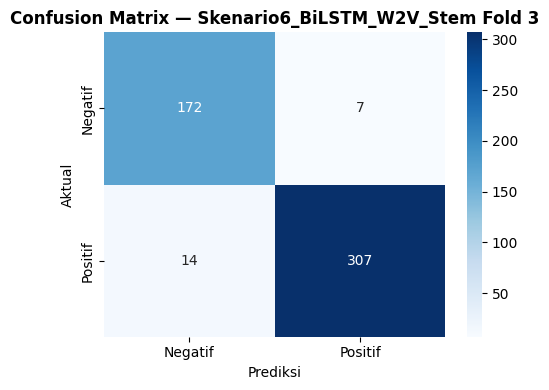

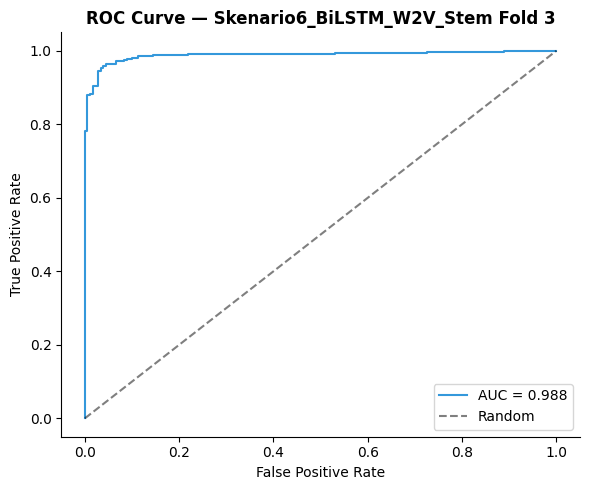


  ── Fold 4/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - accuracy: 0.7575 - auc: 0.8457 - loss: 0.5396 - val_accuracy: 0.8840 - val_auc: 0.9491 - val_loss: 0.3392
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.8970 - auc: 0.9567 - loss: 0.3000 - val_accuracy: 0.8940 - val_auc: 0.9701 - val_loss: 0.2679
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.9225 - auc: 0.9707 - loss: 0.2417 - val_accuracy: 0.9280 - val_auc: 0.9802 - val_loss: 0.2137
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.9355 - auc: 0.9777 - loss: 0.2100 - val_accuracy: 0.9360 - val_auc: 0.9865 - val_loss: 0.1805
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.9445 - auc: 0.9831 - loss: 0.1833 - val_accuracy: 0.9620 - val_auc: 0.9900 - val_loss: 0.1529
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.9505 - auc: 0.9853 - loss: 0.1669 - val_accuracy: 0.9640 - val_auc: 0.989

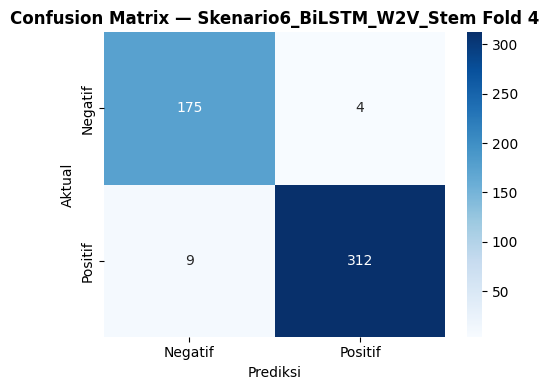

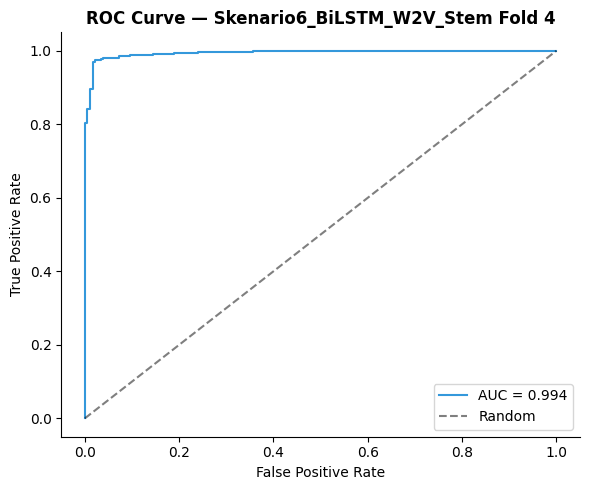


  ── Fold 5/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 169ms/step - accuracy: 0.7565 - auc: 0.8299 - loss: 0.5558 - val_accuracy: 0.9200 - val_auc: 0.9793 - val_loss: 0.2825
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 154ms/step - accuracy: 0.9010 - auc: 0.9555 - loss: 0.3089 - val_accuracy: 0.9440 - val_auc: 0.9896 - val_loss: 0.1772
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.9200 - auc: 0.9680 - loss: 0.2553 - val_accuracy: 0.9580 - val_auc: 0.9916 - val_loss: 0.1691
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.9320 - auc: 0.9771 - loss: 0.2200 - val_accuracy: 0.9600 - val_auc: 0.9928 - val_loss: 0.1347
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 152ms/step - accuracy: 0.9460 - auc: 0.9847 - loss: 0.1797 - val_accuracy: 0.9640 - val_auc: 0.9945 - val_loss: 0.1235
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.9480 - auc: 0.9843 - loss: 0.1755 - val_accuracy: 0.9680 - val_auc: 0.996

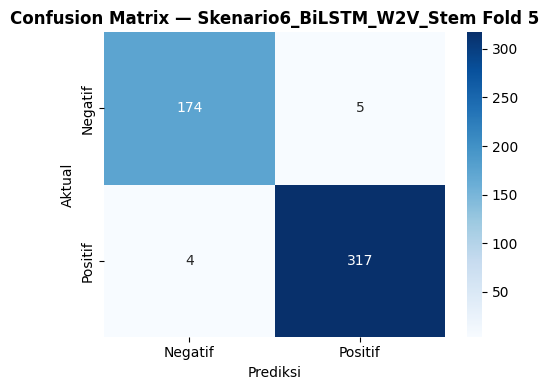

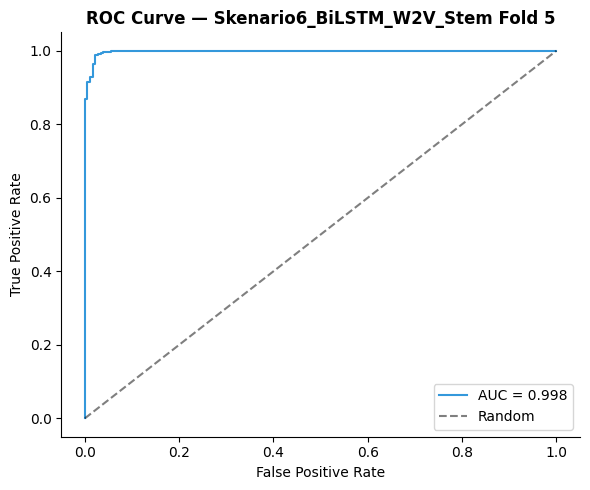


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task5_Service/Skenario6_BiLSTM_W2V_Stem/model.h5


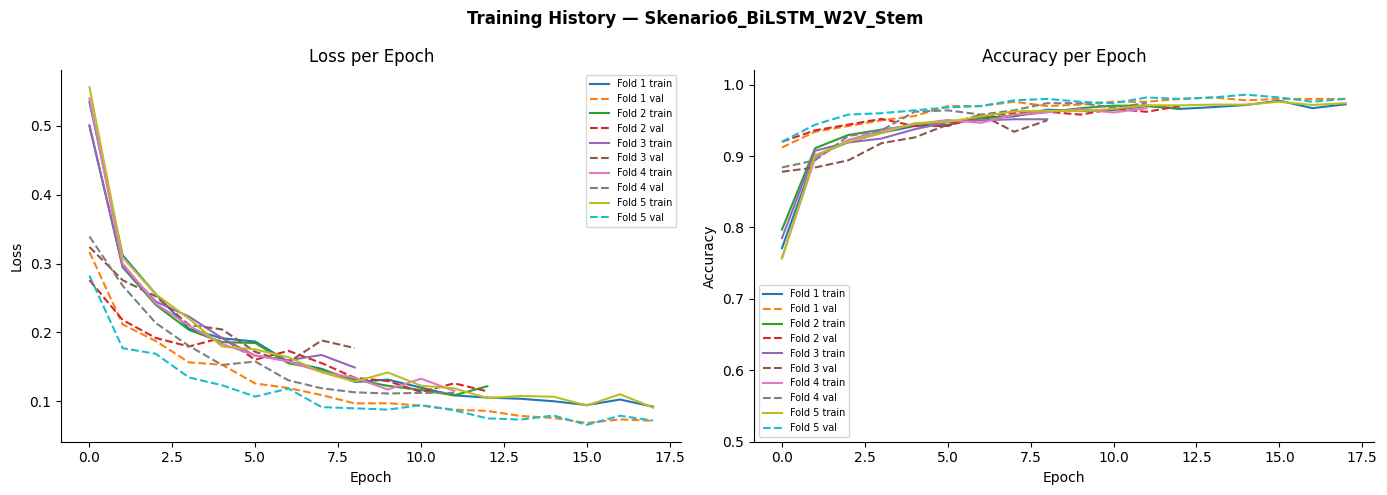


  ╔═ SELESAI: Skenario6_BiLSTM_W2V_Stem
  ║  avg Precision  : 0.9678 ± 0.0118
  ║  avg Recall     : 0.9718 ± 0.0097
  ║  avg F1 Macro   : 0.9697 ± 0.0107
  ║  avg Accuracy   : 0.9720 ± 0.0100
  ║  avg AUC        : 0.9944 ± 0.0042
  ║  avg RAM        : 3541.5 MB (27.3%)
  ║  avg CPU        : 9.6 %
  ║  avg Waktu      : 156.50 detik/fold
  ║  avg T/Epoch    : 11.08 detik/epoch
  ║  avg T/Step     : 0.1788 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 6 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[5])


  Training: Skenario7_BiLSTM_FT_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 165ms/step - accuracy: 0.7275 - auc: 0.7855 - loss: 0.6013 - val_accuracy: 0.8880 - val_auc: 0.9615 - val_loss: 0.3477
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 153ms/step - accuracy: 0.8765 - auc: 0.9411 - loss: 0.3470 - val_accuracy: 0.9160 - val_auc: 0.9764 - val_loss: 0.2910
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.8955 - auc: 0.9573 - loss: 0.2972 - val_accuracy: 0.9280 - val_auc: 0.9830 - val_loss: 0.2276
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - accuracy: 0.9110 - auc: 0.9704 - loss: 0.2543 - val_accuracy: 0.9500 - val_auc: 0.9899 - val_loss: 0.1785
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.9270 - auc: 0.9746 - loss: 0.2320 - val_accu

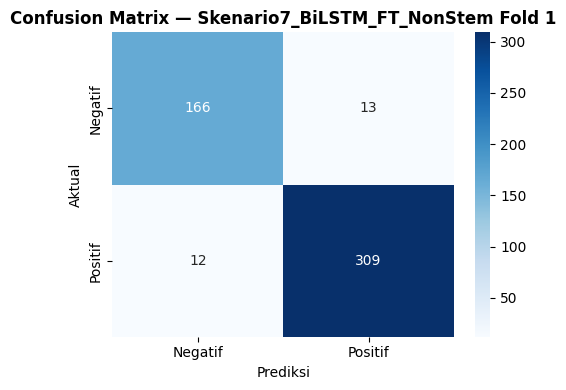

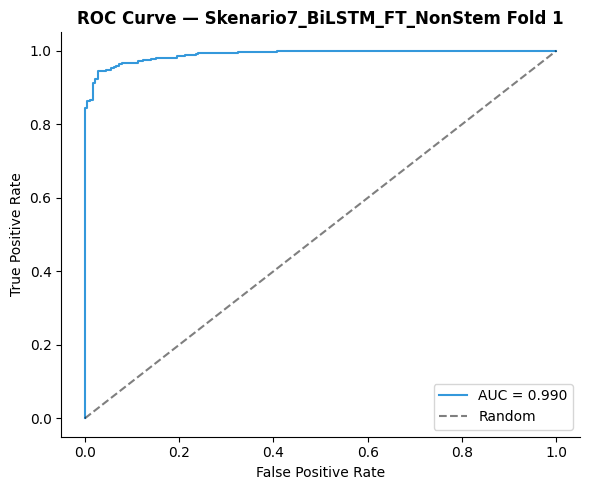


  ── Fold 2/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.7575 - auc: 0.8325 - loss: 0.5595 - val_accuracy: 0.8900 - val_auc: 0.9600 - val_loss: 0.3198
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 152ms/step - accuracy: 0.8840 - auc: 0.9367 - loss: 0.3500 - val_accuracy: 0.9060 - val_auc: 0.9727 - val_loss: 0.2667
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.9010 - auc: 0.9561 - loss: 0.2960 - val_accuracy: 0.9080 - val_auc: 0.9790 - val_loss: 0.2481
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 149ms/step - accuracy: 0.9185 - auc: 0.9673 - loss: 0.2501 - val_accuracy: 0.9360 - val_auc: 0.9806 - val_loss: 0.2110
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.9260 - auc: 0.9732 - loss: 0.2290 - val_accuracy: 0.9520 - val_auc: 0.9864 - val_loss: 0.1797
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.9300 - auc: 0.9771 - loss: 0.2131 - val_accuracy: 0.9360 - val_auc: 0.989

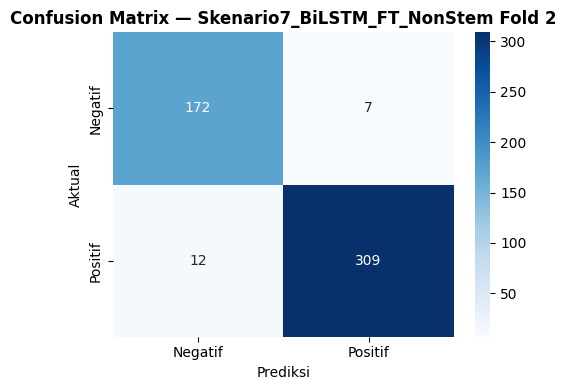

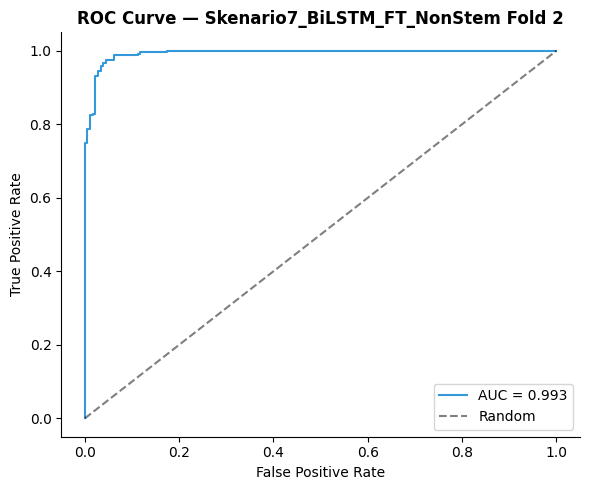


  ── Fold 3/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 164ms/step - accuracy: 0.7560 - auc: 0.8321 - loss: 0.5533 - val_accuracy: 0.8700 - val_auc: 0.9506 - val_loss: 0.3456
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.8920 - auc: 0.9498 - loss: 0.3160 - val_accuracy: 0.8920 - val_auc: 0.9663 - val_loss: 0.3001
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.9110 - auc: 0.9561 - loss: 0.2924 - val_accuracy: 0.8820 - val_auc: 0.9707 - val_loss: 0.2838
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9145 - auc: 0.9716 - loss: 0.2410 - val_accuracy: 0.8860 - val_auc: 0.9722 - val_loss: 0.2838
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.9310 - auc: 0.9761 - loss: 0.2158 - val_accuracy: 0.9300 - val_auc: 0.9798 - val_loss: 0.2059
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.9285 - auc: 0.9822 - loss: 0.1916 - val_accuracy: 0.9360 - val_auc: 0.980

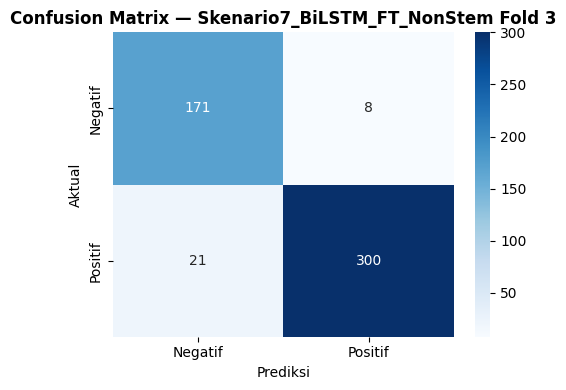

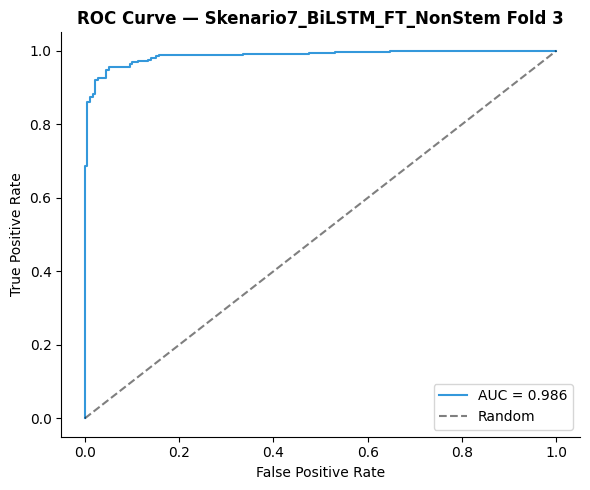


  ── Fold 4/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 171ms/step - accuracy: 0.7535 - auc: 0.8354 - loss: 0.5512 - val_accuracy: 0.8920 - val_auc: 0.9474 - val_loss: 0.3357
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.8910 - auc: 0.9425 - loss: 0.3359 - val_accuracy: 0.9020 - val_auc: 0.9680 - val_loss: 0.2735
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.9030 - auc: 0.9556 - loss: 0.2906 - val_accuracy: 0.9160 - val_auc: 0.9786 - val_loss: 0.2322
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9140 - auc: 0.9696 - loss: 0.2447 - val_accuracy: 0.9320 - val_auc: 0.9852 - val_loss: 0.1912
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.9260 - auc: 0.9762 - loss: 0.2210 - val_accuracy: 0.9420 - val_auc: 0.9868 - val_loss: 0.1882
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.9355 - auc: 0.9756 - loss: 0.2150 - val_accuracy: 0.9380 - val_auc: 0.989

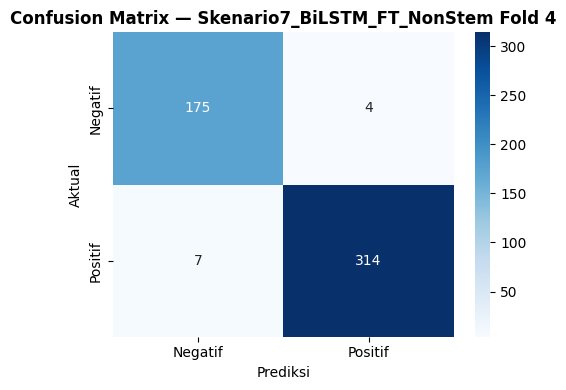

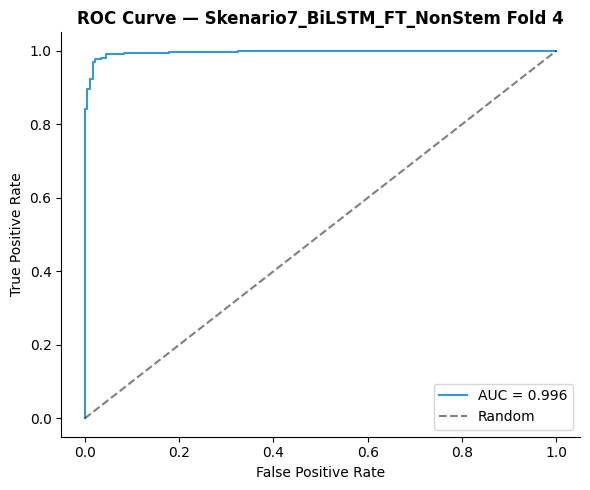


  ── Fold 5/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 166ms/step - accuracy: 0.7110 - auc: 0.7808 - loss: 0.6015 - val_accuracy: 0.8680 - val_auc: 0.9589 - val_loss: 0.3518
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.8755 - auc: 0.9296 - loss: 0.3704 - val_accuracy: 0.9280 - val_auc: 0.9822 - val_loss: 0.2320
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.8955 - auc: 0.9533 - loss: 0.3066 - val_accuracy: 0.9420 - val_auc: 0.9877 - val_loss: 0.1921
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.9080 - auc: 0.9623 - loss: 0.2754 - val_accuracy: 0.9540 - val_auc: 0.9924 - val_loss: 0.1509
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.9235 - auc: 0.9730 - loss: 0.2359 - val_accuracy: 0.9580 - val_auc: 0.9930 - val_loss: 0.1580
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.9385 - auc: 0.9771 - loss: 0.2134 - val_accuracy: 0.9540 - val_auc: 0.9916

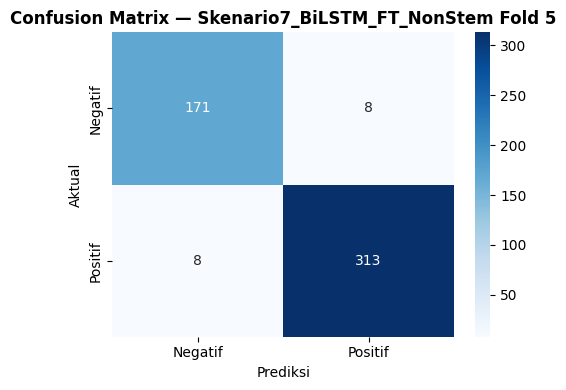

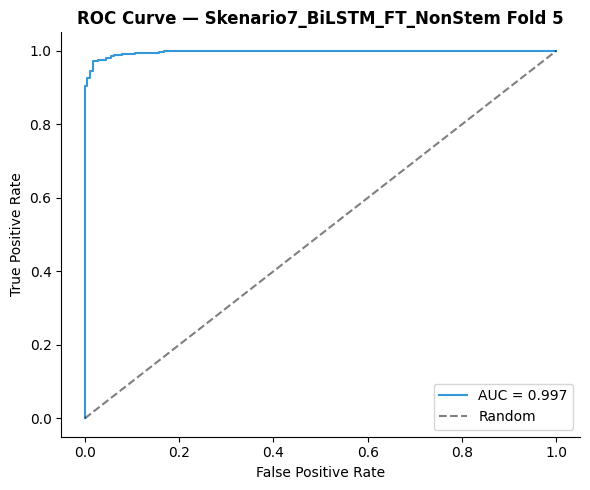


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task5_Service/Skenario7_BiLSTM_FT_NonStem/model.h5


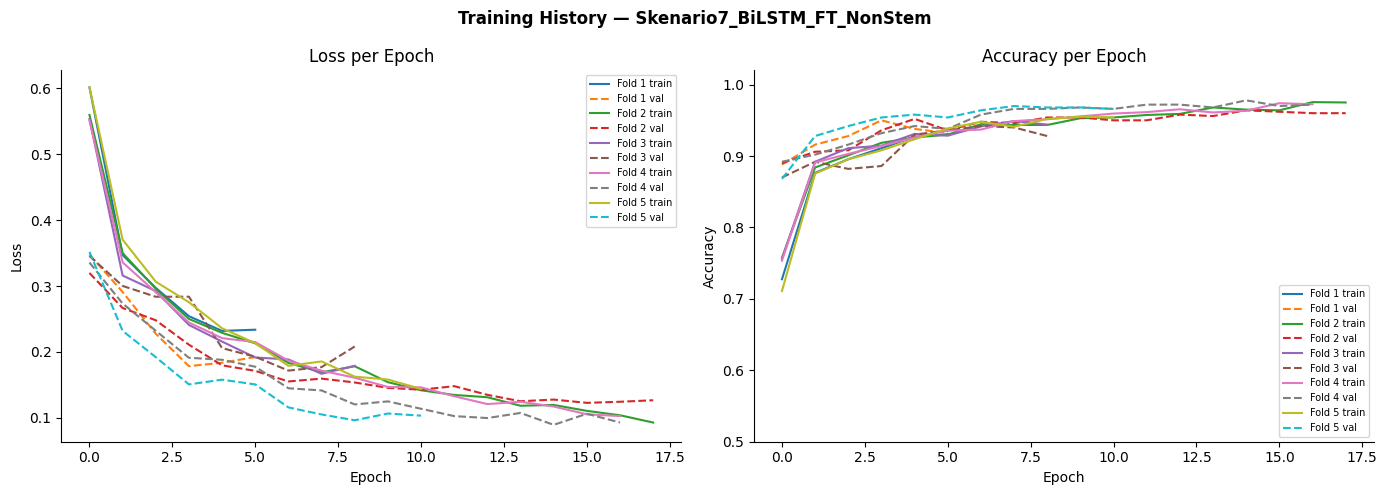


  ╔═ SELESAI: Skenario7_BiLSTM_FT_NonStem
  ║  avg Precision  : 0.9549 ± 0.0164
  ║  avg Recall     : 0.9590 ± 0.0141
  ║  avg F1 Macro   : 0.9567 ± 0.0153
  ║  avg Accuracy   : 0.9600 ± 0.0143
  ║  avg AUC        : 0.9924 ± 0.0044
  ║  avg RAM        : 3910.1 MB (30.1%)
  ║  avg CPU        : 13.8 %
  ║  avg Waktu      : 134.05 detik/fold
  ║  avg T/Epoch    : 11.26 detik/epoch
  ║  avg T/Step     : 0.1816 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 7 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[6])


  Training: Skenario8_BiLSTM_FT_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.7180 - auc: 0.7744 - loss: 0.6134 - val_accuracy: 0.8920 - val_auc: 0.9576 - val_loss: 0.3443
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.8845 - auc: 0.9285 - loss: 0.3669 - val_accuracy: 0.9120 - val_auc: 0.9733 - val_loss: 0.3029
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.8855 - auc: 0.9462 - loss: 0.3180 - val_accuracy: 0.9300 - val_auc: 0.9815 - val_loss: 0.2228
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.9065 - auc: 0.9614 - loss: 0.2666 - val_accuracy: 0.9360 - val_auc: 0.9853 - val_loss: 0.1994
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.9140 - auc: 0.9659 - loss: 0.2489 - val_accuracy

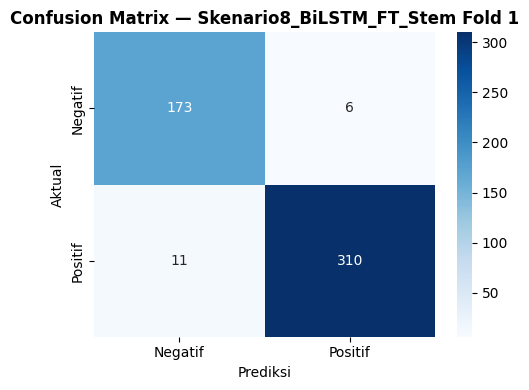

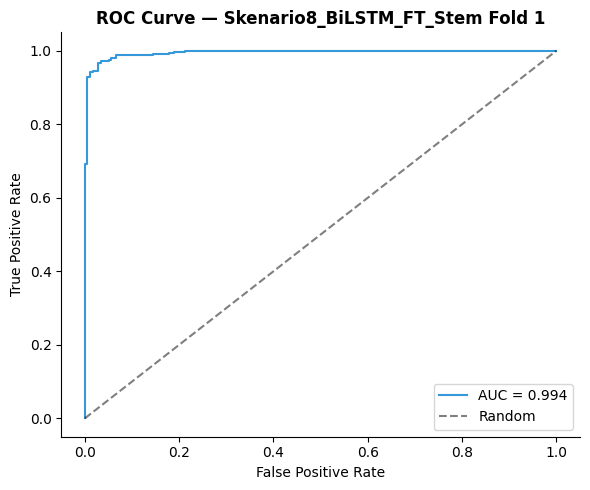


  ── Fold 2/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 149ms/step - accuracy: 0.7440 - auc: 0.8115 - loss: 0.5760 - val_accuracy: 0.8860 - val_auc: 0.9596 - val_loss: 0.3317
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.8685 - auc: 0.9279 - loss: 0.3704 - val_accuracy: 0.8880 - val_auc: 0.9672 - val_loss: 0.3012
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.8965 - auc: 0.9541 - loss: 0.3022 - val_accuracy: 0.9180 - val_auc: 0.9758 - val_loss: 0.2345
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.9170 - auc: 0.9616 - loss: 0.2664 - val_accuracy: 0.9340 - val_auc: 0.9841 - val_loss: 0.1895
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.9145 - auc: 0.9692 - loss: 0.2453 - val_accuracy: 0.9320 - val_auc: 0.9865 - val_loss: 0.2008
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.9380 - auc: 0.9771 - loss: 0.2102 - val_accuracy: 0.9480 - val_auc: 0.98

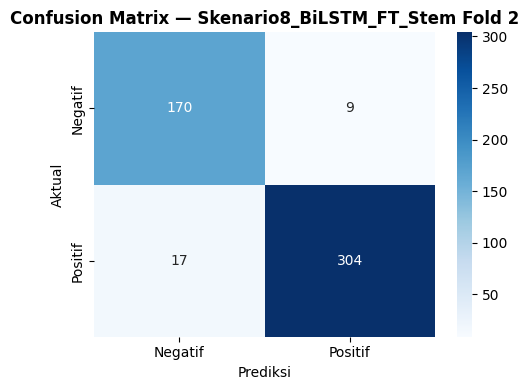

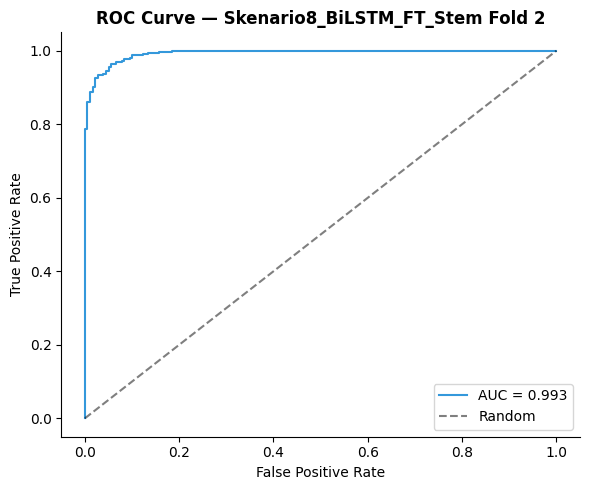


  ── Fold 3/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 168ms/step - accuracy: 0.7360 - auc: 0.8091 - loss: 0.5731 - val_accuracy: 0.8780 - val_auc: 0.9514 - val_loss: 0.3356
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.8800 - auc: 0.9385 - loss: 0.3447 - val_accuracy: 0.8980 - val_auc: 0.9684 - val_loss: 0.2699
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.8980 - auc: 0.9565 - loss: 0.2910 - val_accuracy: 0.8820 - val_auc: 0.9741 - val_loss: 0.2611
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.9125 - auc: 0.9682 - loss: 0.2472 - val_accuracy: 0.9280 - val_auc: 0.9798 - val_loss: 0.2028
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.9230 - auc: 0.9698 - loss: 0.2340 - val_accuracy: 0.9020 - val_auc: 0.9817 - val_loss: 0.2429
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - accuracy: 0.9310 - auc: 0.9768 - loss: 0.2095 - val_accuracy: 0.9320 - val_auc: 0.983

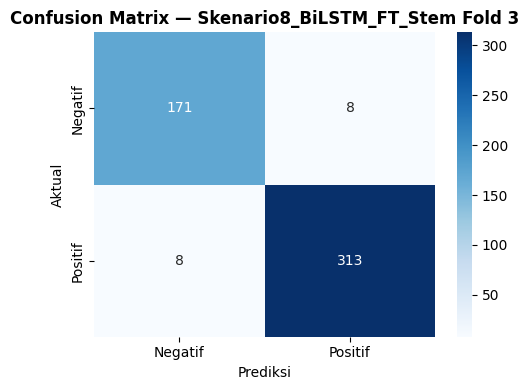

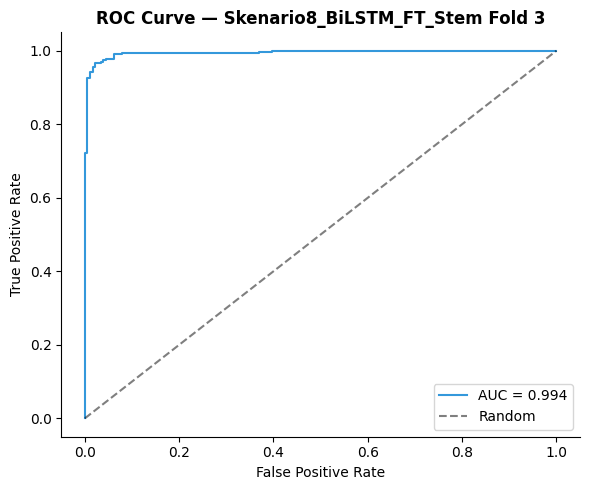


  ── Fold 4/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 172ms/step - accuracy: 0.7465 - auc: 0.8254 - loss: 0.5583 - val_accuracy: 0.8680 - val_auc: 0.9445 - val_loss: 0.3684
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.8830 - auc: 0.9352 - loss: 0.3499 - val_accuracy: 0.8960 - val_auc: 0.9631 - val_loss: 0.2766
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.8990 - auc: 0.9544 - loss: 0.2960 - val_accuracy: 0.9040 - val_auc: 0.9685 - val_loss: 0.2527
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 159ms/step - accuracy: 0.9135 - auc: 0.9628 - loss: 0.2638 - val_accuracy: 0.9260 - val_auc: 0.9779 - val_loss: 0.2112
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.9275 - auc: 0.9770 - loss: 0.2135 - val_accuracy: 0.9340 - val_auc: 0.9820 - val_loss: 0.1962
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.9320 - auc: 0.9795 - loss: 0.2002 - val_accuracy: 0.9460 - val_auc: 0.983

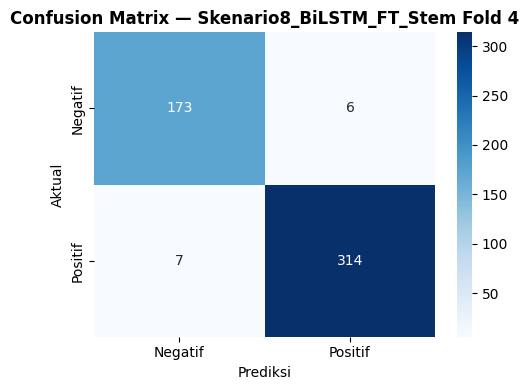

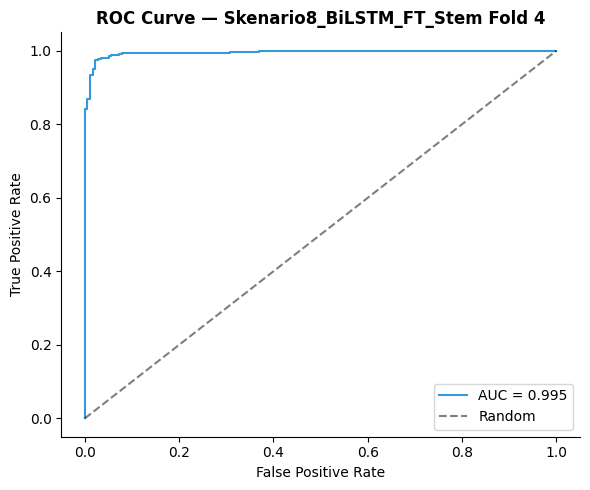


  ── Fold 5/5 ──
  Distribusi train: Pos=1284, Neg=716
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 156ms/step - accuracy: 0.7485 - auc: 0.8222 - loss: 0.5607 - val_accuracy: 0.9060 - val_auc: 0.9714 - val_loss: 0.2849
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.8670 - auc: 0.9311 - loss: 0.3639 - val_accuracy: 0.9380 - val_auc: 0.9829 - val_loss: 0.2107
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 154ms/step - accuracy: 0.9040 - auc: 0.9535 - loss: 0.3028 - val_accuracy: 0.9560 - val_auc: 0.9886 - val_loss: 0.1748
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.9195 - auc: 0.9710 - loss: 0.2457 - val_accuracy: 0.9620 - val_auc: 0.9927 - val_loss: 0.1429
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.9165 - auc: 0.9678 - loss: 0.2482 - val_accuracy: 0.9620 - val_auc: 0.9926 - val_loss: 0.1410
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.9295 - auc: 0.9727 - loss: 0.2268 - val_accuracy: 0.9720 - val_auc: 0.9941

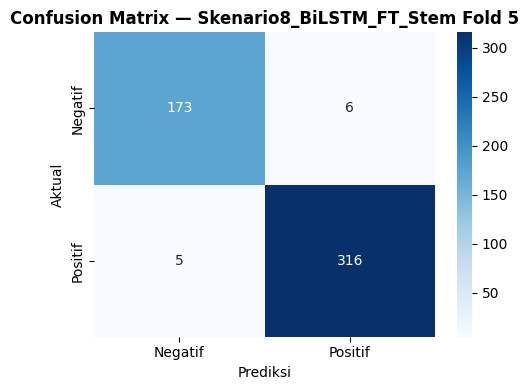

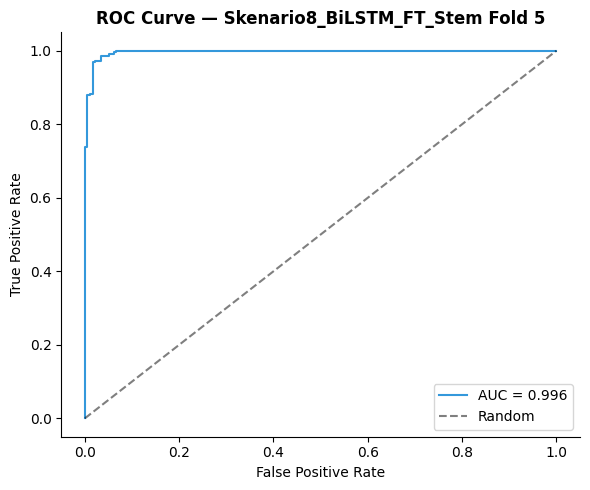


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task5_Service/Skenario8_BiLSTM_FT_Stem/model.h5


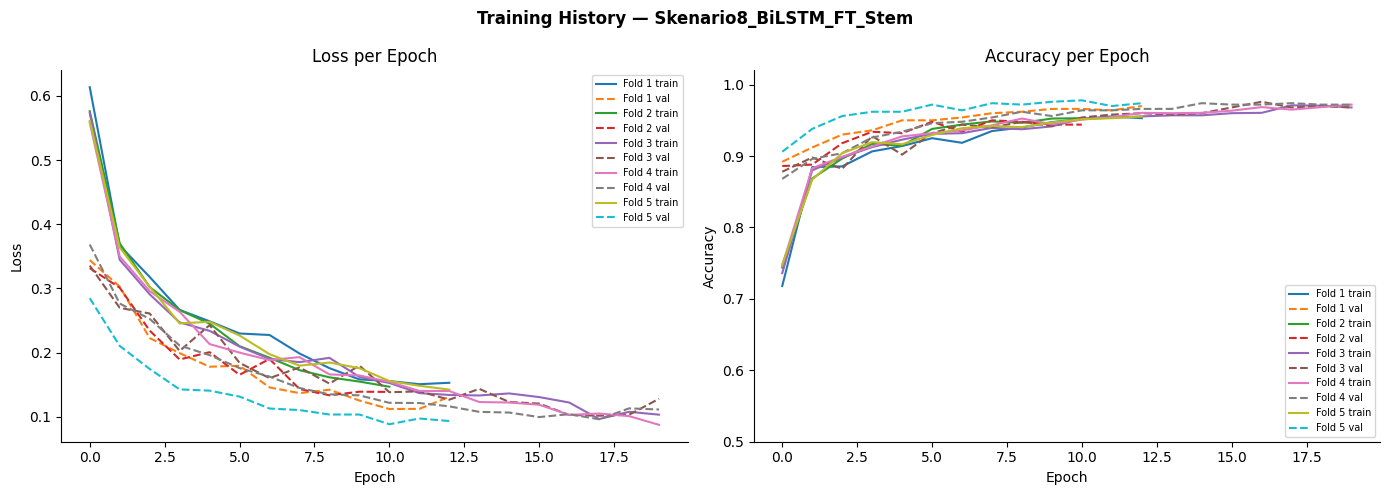


  ╔═ SELESAI: Skenario8_BiLSTM_FT_Stem
  ║  avg Precision  : 0.9628 ± 0.0140
  ║  avg Recall     : 0.9655 ± 0.0105
  ║  avg F1 Macro   : 0.9640 ± 0.0123
  ║  avg Accuracy   : 0.9668 ± 0.0115
  ║  avg AUC        : 0.9947 ± 0.0012
  ║  avg RAM        : 4244.9 MB (32.7%)
  ║  avg CPU        : 12.5 %
  ║  avg Waktu      : 158.59 detik/fold
  ║  avg T/Epoch    : 10.27 detik/epoch
  ║  avg T/Step     : 0.1656 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 8 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[7])

## 8. Rekap Hasil & Simpan ke Excel


In [ ]:
# Load rekap CSV lalu simpan ke Excel
df_rekap = pd.read_csv(OUTPUT_DIR + 'rekap_Task5_semua_skenario.csv')

# Urutkan berdasarkan F1 Macro tertinggi
df_rekap = df_rekap.sort_values('avg_f1_macro', ascending=False).reset_index(drop=True)

print('=== Rekap Semua Skenario (urut F1 Macro) ===')
cols_tampil = ['skenario', 'avg_f1_macro', 'std_f1_macro',
               'avg_accuracy', 'avg_precision_macro',
               'avg_recall_macro', 'avg_auc']
print(df_rekap[cols_tampil].to_string(index=False))

# Simpan ke Excel
excel_path = OUTPUT_DIR + 'rekap_Task5_semua_skenario.xlsx'
df_rekap.to_excel(excel_path, index=False)
print(f'\nDisimpan ke: {excel_path}')

=== Rekap Semua Skenario (urut F1 Macro) ===
                    skenario  avg_f1_macro  std_f1_macro  avg_accuracy  avg_precision_macro  avg_recall_macro  avg_auc
      Skenario2_CNN_W2V_Stem        0.9796        0.0078        0.9812               0.9784            0.9809   0.9973
       Skenario4_CNN_FT_Stem        0.9787        0.0073        0.9804               0.9778            0.9798   0.9970
   Skenario1_CNN_W2V_NonStem        0.9764        0.0044        0.9784               0.9780            0.9750   0.9967
    Skenario3_CNN_FT_NonStem        0.9735        0.0072        0.9756               0.9733            0.9738   0.9966
Skenario5_BiLSTM_W2V_NonStem        0.9707        0.0096        0.9732               0.9724            0.9692   0.9944
   Skenario6_BiLSTM_W2V_Stem        0.9697        0.0107        0.9720               0.9678            0.9718   0.9944
    Skenario8_BiLSTM_FT_Stem        0.9640        0.0123        0.9668               0.9628            0.9655   0.9947
 Sk

In [ ]:
# Load rekap CSV lalu simpan ke Excel
df_rekap = pd.read_csv(OUTPUT_DIR + 'rekap_Task5_semua_skenario.csv')

# Urutkan berdasarkan F1 Macro tertinggi
df_rekap = df_rekap.sort_values('avg_f1_macro', ascending=False).reset_index(drop=True)
df_rekap.insert(0, 'rank', range(1, len(df_rekap) + 1))

print('='*100)
print('  REKAP SEMUA SKENARIO TASK 5 — SENTIMEN SERVICE')
print('  Diurutkan berdasarkan F1 Macro Tertinggi')
print('='*100)

# Tampilkan per kelompok metrik
cols_utama = ['rank', 'skenario',
              'avg_f1_macro', 'std_f1_macro',
              'avg_precision_macro', 'std_precision_macro',
              'avg_recall_macro', 'std_recall_macro',
              'avg_accuracy', 'std_accuracy',
              'avg_auc', 'std_auc']

cols_resource = ['rank', 'skenario',
    'avg_waktu_training',  'std_waktu_training',
    'avg_waktu_inference', 'std_waktu_inference',
    'avg_time_per_epoch',  'std_time_per_epoch',
    'avg_time_per_step',   'std_time_per_step',
    'avg_ram_mb',          'std_ram_mb',
    'avg_ram_pct',         'std_ram_pct',
    'avg_cpu_pct',         'std_cpu_pct',
    'avg_epoch_berhenti',  'std_epoch_berhenti']

# Filter kolom yang ada saja
cols_utama    = [c for c in cols_utama    if c in df_rekap.columns]
cols_resource = [c for c in cols_resource if c in df_rekap.columns]

print('\n── Metrik Performa ──')
print(df_rekap[cols_utama].to_string(index=False))

print('\n── Resource Usage ──')
print(df_rekap[cols_resource].to_string(index=False))

# Highlight model terbaik
best = df_rekap.iloc[0]
print('\n' + '='*100)
print(f'     MODEL TERBAIK : {best["skenario"]}')
print(f'     F1 Macro     : {best["avg_f1_macro"]:.4f} ± {best["std_f1_macro"]:.4f}')
print(f'     Precision    : {best["avg_precision_macro"]:.4f} ± {best["std_precision_macro"]:.4f}')
print(f'     Recall       : {best["avg_recall_macro"]:.4f} ± {best["std_recall_macro"]:.4f}')
print(f'     Accuracy     : {best["avg_accuracy"]:.4f} ± {best["std_accuracy"]:.4f}')
print(f'     AUC          : {best["avg_auc"]:.4f} ± {best["std_auc"]:.4f}')
print('='*100)

# Simpan ke Excel dengan formatting
excel_path = OUTPUT_DIR + 'rekap_Task5_semua_skenario.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Sheet 1: Semua metrik
    df_rekap.to_excel(writer, sheet_name='Rekap_Lengkap', index=False)

    # Sheet 2: Ringkasan
    cols_ringkasan = [c for c in [
        'rank', 'skenario',
        'avg_f1_macro', 'std_f1_macro',
        'avg_precision_macro', 'avg_recall_macro',
        'avg_accuracy', 'avg_auc',
        'avg_waktu_training', 'avg_ram_mb'
    ] if c in df_rekap.columns]

    df_rekap[cols_ringkasan].to_excel(
        writer, sheet_name='Ringkasan', index=False
    )

print(f'\n✅ Disimpan ke : {excel_path}')

  REKAP SEMUA SKENARIO TASK 5 — SENTIMEN SERVICE
  Diurutkan berdasarkan F1 Macro Tertinggi

── Metrik Performa ──
 rank                     skenario  avg_f1_macro  std_f1_macro  avg_precision_macro  std_precision_macro  avg_recall_macro  std_recall_macro  avg_accuracy  std_accuracy  avg_auc  std_auc
    1       Skenario2_CNN_W2V_Stem        0.9796        0.0078               0.9784               0.0083            0.9809            0.0073        0.9812        0.0072   0.9973   0.0012
    2        Skenario4_CNN_FT_Stem        0.9787        0.0073               0.9778               0.0091            0.9798            0.0055        0.9804        0.0068   0.9970   0.0018
    3    Skenario1_CNN_W2V_NonStem        0.9764        0.0044               0.9780               0.0059            0.9750            0.0033        0.9784        0.0041   0.9967   0.0021
    4     Skenario3_CNN_FT_NonStem        0.9735        0.0072               0.9733               0.0089            0.9738            0.0


Plot: Skenario1_CNN_W2V_NonStem


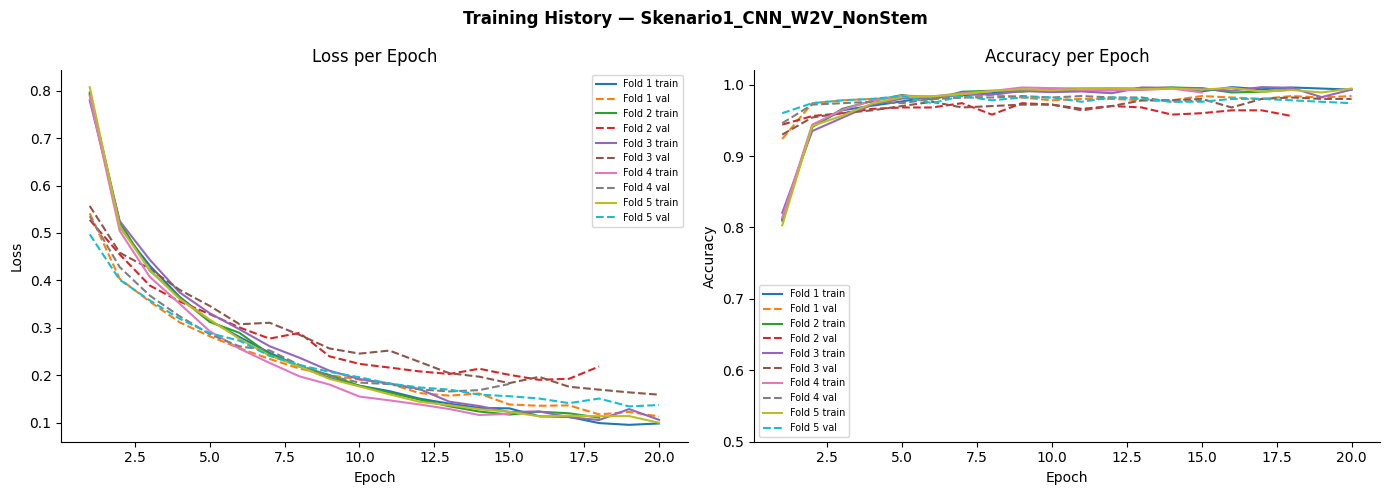

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Model/Task5_Service_Coba/Skenario1_CNN_W2V_NonStem/training_history_accuracy.png

Plot: Skenario2_CNN_W2V_Stem


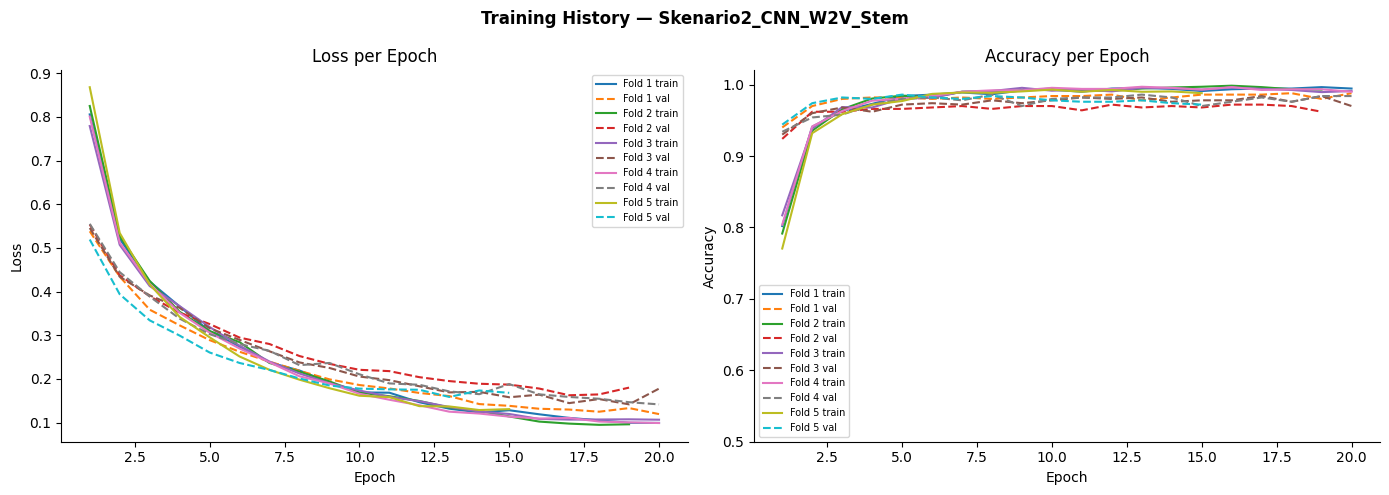

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Model/Task5_Service_Coba/Skenario2_CNN_W2V_Stem/training_history_accuracy.png

Plot: Skenario3_CNN_FT_NonStem


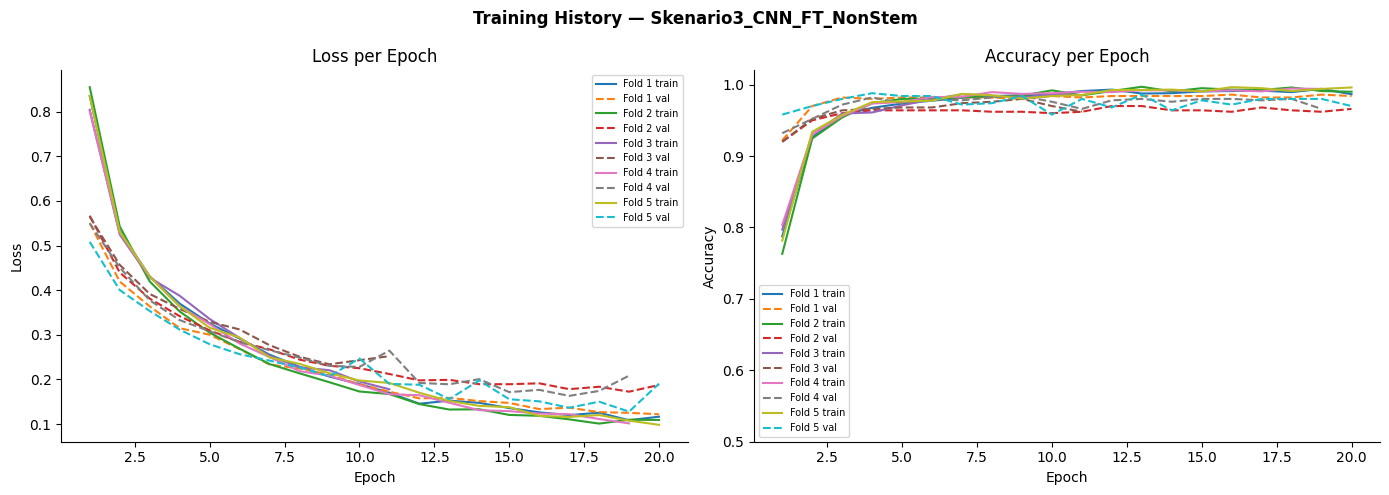

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Model/Task5_Service_Coba/Skenario3_CNN_FT_NonStem/training_history_accuracy.png

Plot: Skenario4_CNN_FT_Stem


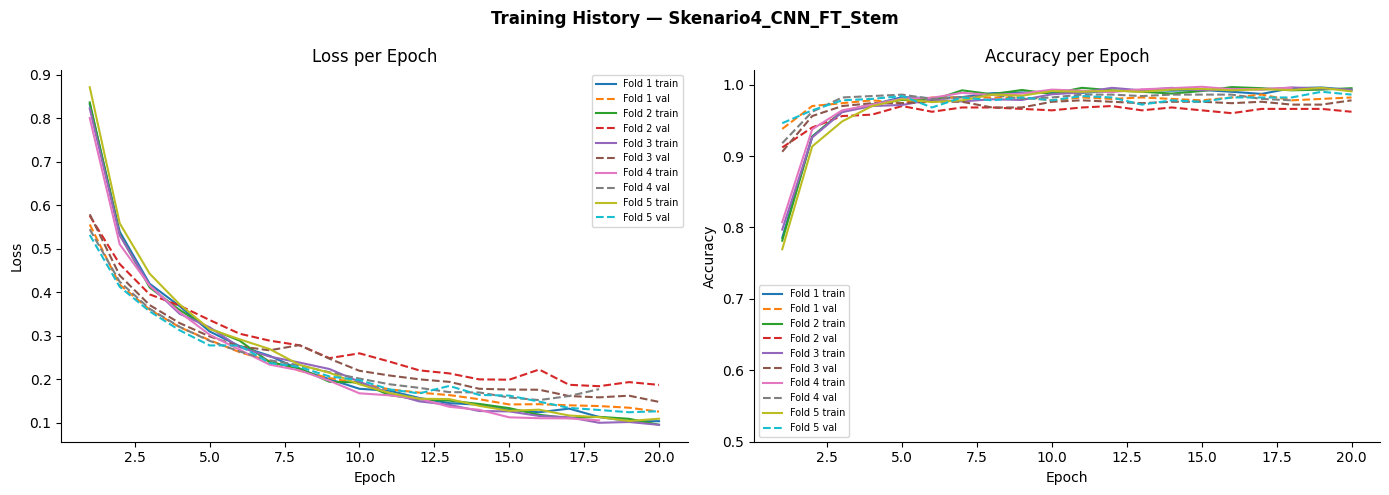

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Model/Task5_Service_Coba/Skenario4_CNN_FT_Stem/training_history_accuracy.png

Plot: Skenario5_BiLSTM_W2V_NonStem


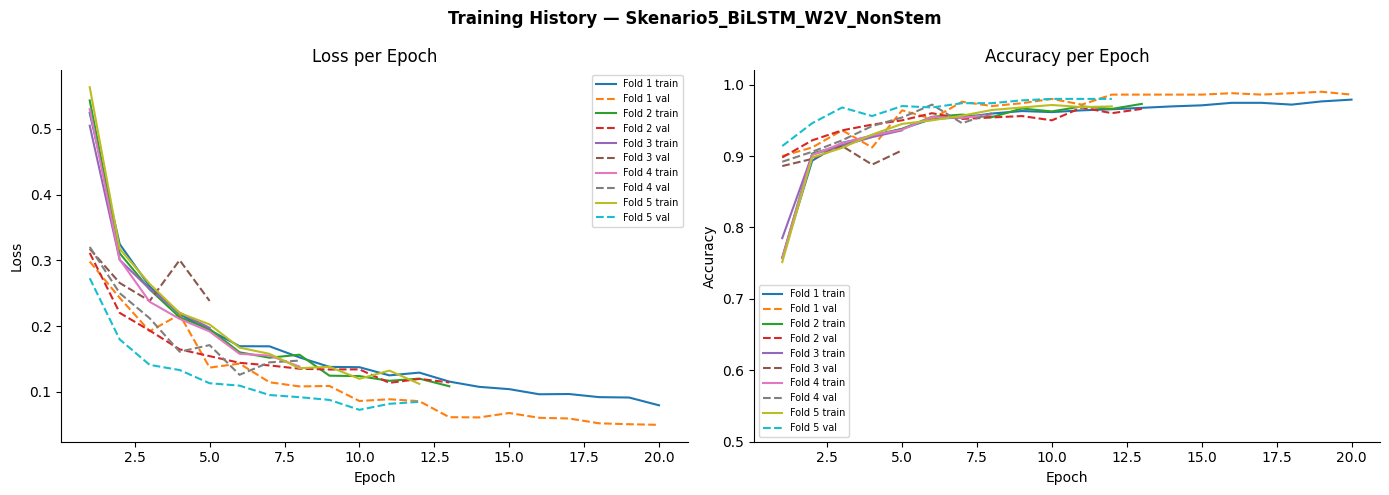

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Model/Task5_Service_Coba/Skenario5_BiLSTM_W2V_NonStem/training_history_accuracy.png

Plot: Skenario6_BiLSTM_W2V_Stem


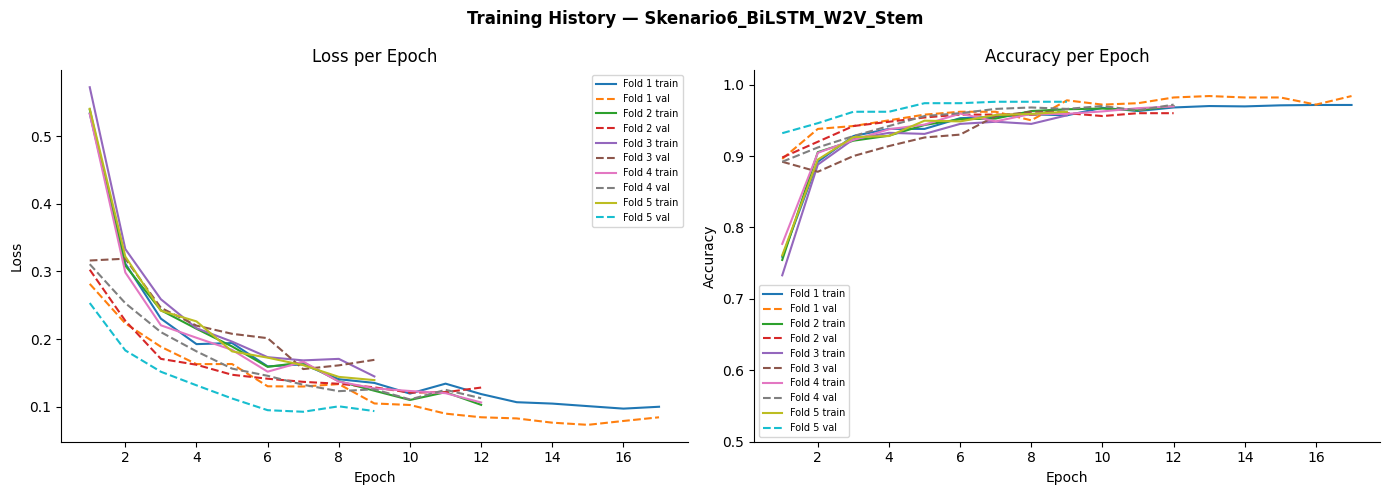

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Model/Task5_Service_Coba/Skenario6_BiLSTM_W2V_Stem/training_history_accuracy.png

Plot: Skenario7_BiLSTM_FT_NonStem


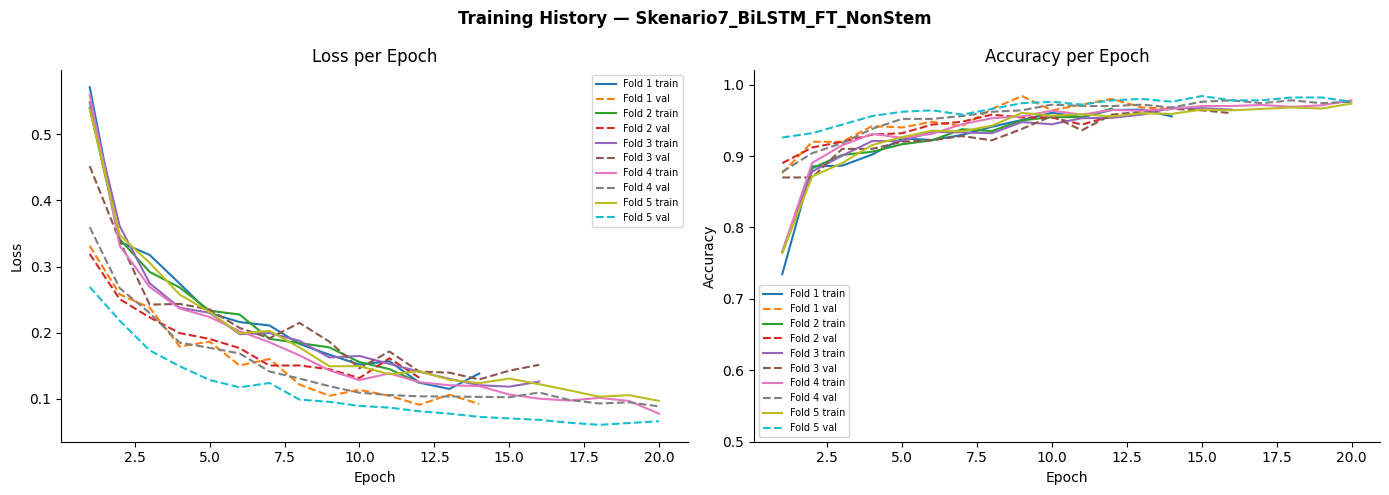

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Model/Task5_Service_Coba/Skenario7_BiLSTM_FT_NonStem/training_history_accuracy.png

Plot: Skenario8_BiLSTM_FT_Stem


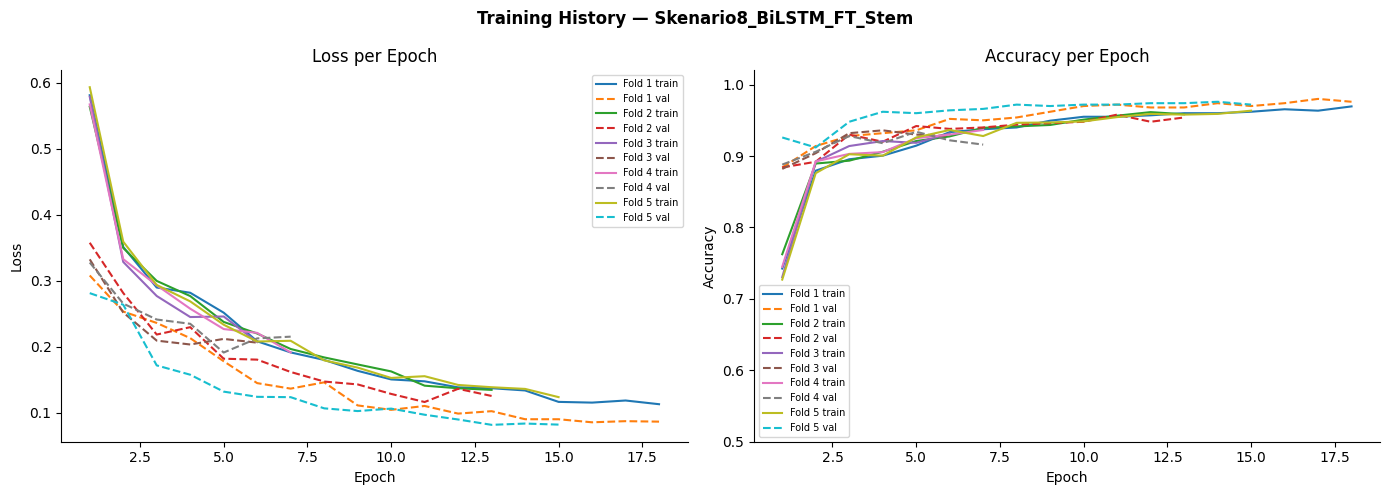

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Model/Task5_Service_Coba/Skenario8_BiLSTM_FT_Stem/training_history_accuracy.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_ulang_dari_csv(skenario_dir, nama_skenario):
    # Load history CSV
    df = pd.read_csv(skenario_dir + 'history_per_fold.csv')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for fold_ke in sorted(df['fold'].unique()):
        df_fold = df[df['fold'] == fold_ke]
        label   = f'Fold {fold_ke}'

        # Loss
        axes[0].plot(df_fold['epoch'], df_fold['loss'],
                     linestyle='-',  label=f'{label} train')
        axes[0].plot(df_fold['epoch'], df_fold['val_loss'],
                     linestyle='--', label=f'{label} val')

        # Accuracy
        axes[1].plot(df_fold['epoch'], df_fold['accuracy'],
                     linestyle='-',  label=f'{label} train')
        axes[1].plot(df_fold['epoch'], df_fold['val_accuracy'],
                     linestyle='--', label=f'{label} val')

    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=7)
    axes[0].spines[['top','right']].set_visible(False)

    axes[1].set_title('Accuracy per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.5, 1.02)
    axes[1].legend(fontsize=7)
    axes[1].spines[['top','right']].set_visible(False)

    plt.suptitle(f'Training History — {nama_skenario}', fontweight='bold')
    plt.tight_layout()

    # Simpan
    output_path = skenario_dir + 'training_history_accuracy.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'✅ Disimpan: {output_path}')


# ── Jalankan untuk semua skenario Task 5 ──
BASE_DIR    = '/content/drive/MyDrive/SKRIPSI_NAVY/'
TASK5_DIR   = BASE_DIR + 'Dataset/Dataset_Modelling/Task5_Service/'

skenario_list = [
    'Skenario1_CNN_W2V_NonStem',
    'Skenario2_CNN_W2V_Stem',
    'Skenario3_CNN_FT_NonStem',
    'Skenario4_CNN_FT_Stem',
    'Skenario5_BiLSTM_W2V_NonStem',
    'Skenario6_BiLSTM_W2V_Stem',
    'Skenario7_BiLSTM_FT_NonStem',
    'Skenario8_BiLSTM_FT_Stem',
]

for nama in skenario_list:
    path = TASK5_DIR + nama + '/'
    csv  = path + 'history_per_fold.csv'
    if os.path.exists(csv):
        print(f'\nPlot: {nama}')
        plot_ulang_dari_csv(path, nama)
    else:
        print(f'Skip {nama} — belum ada CSV')

## 9. Rekomendasi Model Terbaik


In [ ]:
# Model terbaik = F1 Macro tertinggi
model_terbaik = df_rekap.iloc[0]
print('=== Model Terbaik Task 5 ===')
print(f"Skenario    : {model_terbaik['skenario']}")
print(f"avg F1 Macro: {model_terbaik['avg_f1_macro']:.4f} ± {model_terbaik['std_f1_macro']:.4f}")
print(f"avg Accuracy: {model_terbaik['avg_accuracy']:.4f}")
print(f"avg AUC     : {model_terbaik['avg_auc']:.4f}")


=== Model Terbaik Task 5 ===
Skenario    : Skenario2_CNN_W2V_Stem
avg F1 Macro: 0.9796 ± 0.0078
avg Accuracy: 0.9812
avg AUC     : 0.9973


## 10. Visualisasi Perbandingan Semua Skenario


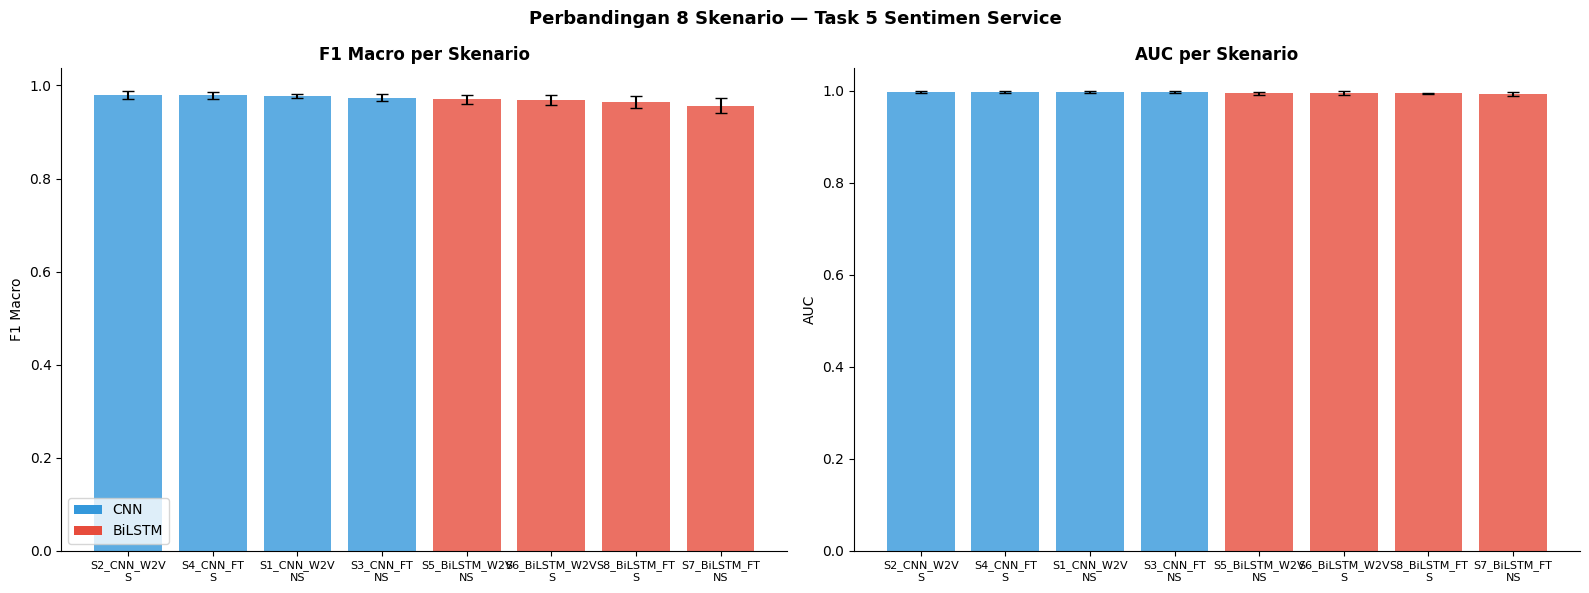

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#3498db' if 'CNN' in s else '#e74c3c'
          for s in df_rekap['skenario']]
labels_short = [s.replace('Skenario','S').replace('_NonStem','\nNS').replace('_Stem','\nS')
                for s in df_rekap['skenario']]

# F1 Macro
bars = axes[0].bar(range(len(df_rekap)), df_rekap['avg_f1_macro'],
                   color=colors, alpha=0.8)
axes[0].errorbar(range(len(df_rekap)), df_rekap['avg_f1_macro'],
                 yerr=df_rekap['std_f1_macro'], fmt='none',
                 color='black', capsize=4)
axes[0].set_xticks(range(len(df_rekap)))
axes[0].set_xticklabels(labels_short, fontsize=8)
axes[0].set_title('F1 Macro per Skenario', fontweight='bold')
axes[0].set_ylabel('F1 Macro')
axes[0].spines[['top','right']].set_visible(False)

# AUC
axes[1].bar(range(len(df_rekap)), df_rekap['avg_auc'],
            color=colors, alpha=0.8)
axes[1].errorbar(range(len(df_rekap)), df_rekap['avg_auc'],
                 yerr=df_rekap['std_auc'], fmt='none',
                 color='black', capsize=4)
axes[1].set_xticks(range(len(df_rekap)))
axes[1].set_xticklabels(labels_short, fontsize=8)
axes[1].set_title('AUC per Skenario', fontweight='bold')
axes[1].set_ylabel('AUC')
axes[1].spines[['top','right']].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='CNN'),
    Patch(facecolor='#e74c3c', label='BiLSTM')
]
axes[0].legend(handles=legend_elements)

plt.suptitle('Perbandingan 8 Skenario — Task 5 Sentimen Service',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'perbandingan_skenario_Task5.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 11. Dummy Classifier

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report

# ============================================================
# DUMMY CLASSIFIER BASELINE — Task 5 Sentimen Service
# (LABEL_COL sesuai task masing-masing)
# ============================================================

print('='*60)
print('  DUMMY CLASSIFIER BASELINE')
print('  Strategi: majority class (tebak kelas terbanyak)')
print('='*60)

# Data train dan test sudah ada dari cell sebelumnya
# y_train = label training
# y_test  = label test (load dulu kalau belum)

# Kalau y_test belum ada, load dulu:
df_test  = pd.read_csv(SPLIT_DIR + 'df_test_Task5_Service.csv')
y_test   = df_test[LABEL_COL].values

print(f'\n  Distribusi data train:')
print(f'  Positif : {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)')
print(f'  Negatif : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)')

print(f'\n  Distribusi data test:')
print(f'  Positif : {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)')
print(f'  Negatif : {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)')

# Strategi 1: most_frequent (tebak majority class)
dummy_majority = DummyClassifier(strategy='most_frequent')
dummy_majority.fit(y_train.reshape(-1,1), y_train)
y_pred_majority = dummy_majority.predict(y_test.reshape(-1,1))

# Strategi 2: stratified (tebak random sesuai proporsi)
dummy_stratified = DummyClassifier(strategy='stratified',
                                    random_state=42)
dummy_stratified.fit(y_train.reshape(-1,1), y_train)
y_pred_stratified = dummy_stratified.predict(y_test.reshape(-1,1))

# Hitung F1
f1_majority   = f1_score(y_test, y_pred_majority,
                          average='macro', zero_division=0)
f1_stratified = f1_score(y_test, y_pred_stratified,
                          average='macro', zero_division=0)

print(f'\n  Hasil Dummy Classifier:')
print(f'  {"Strategi":<20} {"F1 Macro":>10}')
print(f'  {"-"*32}')
print(f'  {"Most Frequent":<20} {f1_majority:>10.4f}')
print(f'  {"Stratified":<20} {f1_stratified:>10.4f}')

print(f'\n  Classification Report — Most Frequent:')
print(classification_report(
    y_test, y_pred_majority,
    target_names=['Negatif', 'Positif'],
    zero_division=0
))

print('='*60)
print('  PERBANDINGAN MODEL vs DUMMY')
print('='*60)

# Ambil F1 terbaik dari rekap kalau sudah ada
try:
    df_rekap = pd.read_csv(OUTPUT_DIR + 'rekap_Task5_semua_skenario.csv')
    best_f1  = df_rekap['avg_f1_macro'].max()
    best_sk  = df_rekap.loc[df_rekap['avg_f1_macro'].idxmax(), 'skenario']
    print(f'  Model terbaik : {best_sk}')
    print(f'  F1 model      : {best_f1:.4f}')
    print(f'  F1 dummy      : {f1_majority:.4f}')
    print(f'  Selisih       : +{best_f1 - f1_majority:.4f}')
    print(f'\n  → Model {((best_f1/max(f1_majority,0.0001))-1)*100:.0f}% '
          f'lebih baik dari dummy!')
except:
    print(f'  F1 dummy (majority)   : {f1_majority:.4f}')
    print(f'  F1 dummy (stratified) : {f1_stratified:.4f}')
    print(f'  → Bandingkan dengan F1 model setelah training selesai')

print('='*60)

  DUMMY CLASSIFIER BASELINE
  Strategi: majority class (tebak kelas terbanyak)

  Distribusi data train:
  Positif : 1605 (64.2%)
  Negatif : 895 (35.8%)

  Distribusi data test:
  Positif : 179 (64.2%)
  Negatif : 100 (35.8%)

  Hasil Dummy Classifier:
  Strategi               F1 Macro
  --------------------------------
  Most Frequent            0.3908
  Stratified               0.4359

  Classification Report — Most Frequent:
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00       100
     Positif       0.64      1.00      0.78       179

    accuracy                           0.64       279
   macro avg       0.32      0.50      0.39       279
weighted avg       0.41      0.64      0.50       279

  PERBANDINGAN MODEL vs DUMMY
  Model terbaik : Skenario2_CNN_W2V_Stem
  F1 model      : 0.9796
  F1 dummy      : 0.3908
  Selisih       : +0.5888

  → Model 151% lebih baik dari dummy!


In [ ]:
import pandas as pd
import os

tasks = {
    'Task2': '/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Model/Task2_Room_Coba/',
    'Task3': '/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Model/Task3_Hotel_Coba/',
    'Task4': '/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Model/Task4_Location_Coba/',
    'Task5': '/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Model/Task5_Service_Coba/',
}

for task, path in tasks.items():
    rekap_path = path + f'rekap_{task}_semua_skenario.csv'
    try:
        df = pd.read_csv(rekap_path)
        print(f'\n{task}:')
        if 'avg_epoch_berhenti' in df.columns:
            for _, row in df.iterrows():
                print(f'  {row["skenario"]:<35} '
                      f'epoch={row["avg_epoch_berhenti"]:.1f}')
        else:
            # Cek dari metrics_per_fold.csv per skenario
            print('  avg_epoch_berhenti tidak ada di rekap')
            print('  Cek per skenario...')
            skenario_list = [
                'Skenario1_CNN_W2V_NonStem',
                'Skenario2_CNN_W2V_Stem',
                'Skenario3_CNN_FT_NonStem',
                'Skenario4_CNN_FT_Stem',
                'Skenario5_BiLSTM_W2V_NonStem',
                'Skenario6_BiLSTM_W2V_Stem',
                'Skenario7_BiLSTM_FT_NonStem',
                'Skenario8_BiLSTM_FT_Stem',
            ]
            for sk in skenario_list:
                m_path = path + sk + '/metrics_per_fold.csv'
                if os.path.exists(m_path):
                    df_m = pd.read_csv(m_path)
                    if 'epoch_berhenti' in df_m.columns:
                        avg_ep = df_m['epoch_berhenti'].mean()
                        print(f'  {sk:<35} epoch={avg_ep:.1f}')
    except FileNotFoundError:
        print(f'\n{task}: rekap CSV tidak ditemukan di {rekap_path}')


Task2:
  avg_epoch_berhenti tidak ada di rekap
  Cek per skenario...
  Skenario1_CNN_W2V_NonStem           epoch=18.4
  Skenario2_CNN_W2V_Stem              epoch=20.0
  Skenario3_CNN_FT_NonStem            epoch=18.8
  Skenario4_CNN_FT_Stem               epoch=16.4
  Skenario5_BiLSTM_W2V_NonStem        epoch=12.6
  Skenario6_BiLSTM_W2V_Stem           epoch=16.8
  Skenario7_BiLSTM_FT_NonStem         epoch=14.2
  Skenario8_BiLSTM_FT_Stem            epoch=15.8

Task3:
  avg_epoch_berhenti tidak ada di rekap
  Cek per skenario...
  Skenario1_CNN_W2V_NonStem           epoch=14.2
  Skenario2_CNN_W2V_Stem              epoch=19.0
  Skenario3_CNN_FT_NonStem            epoch=13.2
  Skenario4_CNN_FT_Stem               epoch=13.6
  Skenario5_BiLSTM_W2V_NonStem        epoch=17.0

Task4:
  avg_epoch_berhenti tidak ada di rekap
  Cek per skenario...
  Skenario1_CNN_W2V_NonStem           epoch=17.6
  Skenario2_CNN_W2V_Stem              epoch=17.6
  Skenario3_CNN_FT_NonStem            epoch=15.0
  Sken